# DEF-D Fysieke Ontwerpopdracht 4 invul template
Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie groepsnummer, studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 21     |  |
| :-------------|:-------------|
| Nynke Bouwhuis| 6508049 |
| Wobbe van der Woude| 6581099 |
| Jesse Langenberg | 6290116 |

In [1]:
# Vul ook hieronder jullie voornamen in en run deze cel.
# Dat is nodig voor de code die je verderop in dit notebook gaat runnen.

studentNames = ['Wobbe','Jesse']

## Opdracht 1: Planning.

| Planning Groep: 21     |Tijdstip / Tijdspanne  |
|---|---|
| Opdracht 2 af (kalibreren) | 12.30 |
| Def algoritme af | 17.00 |
| groep aanwezig 1| 11.00-12.30 |
| groep aanwezig 2| 13.30-17.30 |
| Pauze 1| 12.30-13.30 |

## Opdracht 2: Import libs.

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time

# Dit is onze eigen library waar het imaging algoritme in staat
import imagingDEF2024 as imagingDEF

## Opdracht 3: Kalibratie sensor en foto

kalibratie-opstelling groep [21]
<img src="Kalibratiemeting1.png" width="400">

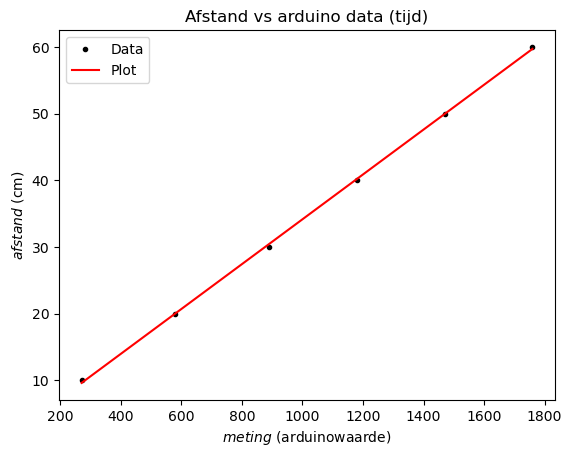

0.033612088728165235 0.5476090536307088


In [3]:
# verwerk hier jullie kalibratiemetingen

from scipy.optimize import curve_fit

afstand = np.array([10,20,30,40,50,60]) #m
meting = np.array([270,580,890,1180,1470,1760]) 

def function(x,a,b): #meting erin, afstand eruit
    y = a*x + b
    return y

pcov, popt = curve_fit(function, meting, afstand)

a_fit, b_fit = pcov

plt.figure()
plt.title('Afstand vs arduino data (tijd)')
plt.plot(meting, afstand, 'k.', label='Data')
plt.plot(meting, function(meting, a_fit, b_fit), color = 'red', label='Plot')
plt.xlabel('$meting$ (arduinowaarde)')
plt.ylabel('$afstand$ (cm)')
plt.legend()
plt.show()

print(a_fit, b_fit)

## Opdracht 4: Test meeting

Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0   0  40   0  30  41.9
1   0  30   0  20  40.2
2  40   0  30   0  40.5
3  30   0  20   0  41.1


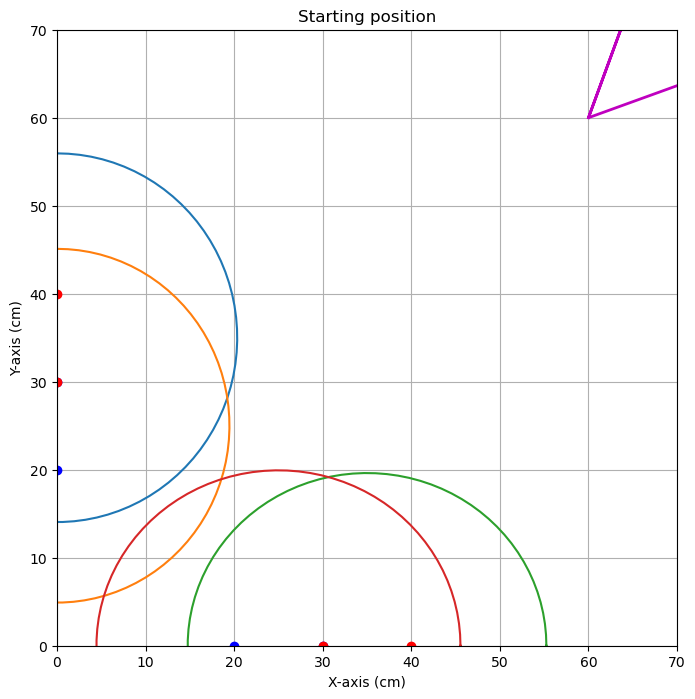


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=101.030


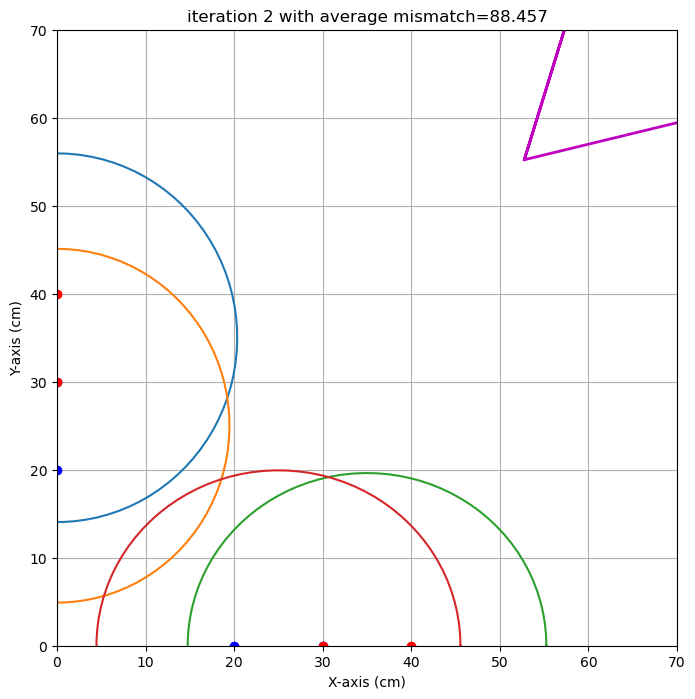

end iteration 2 with average mismatch=88.457


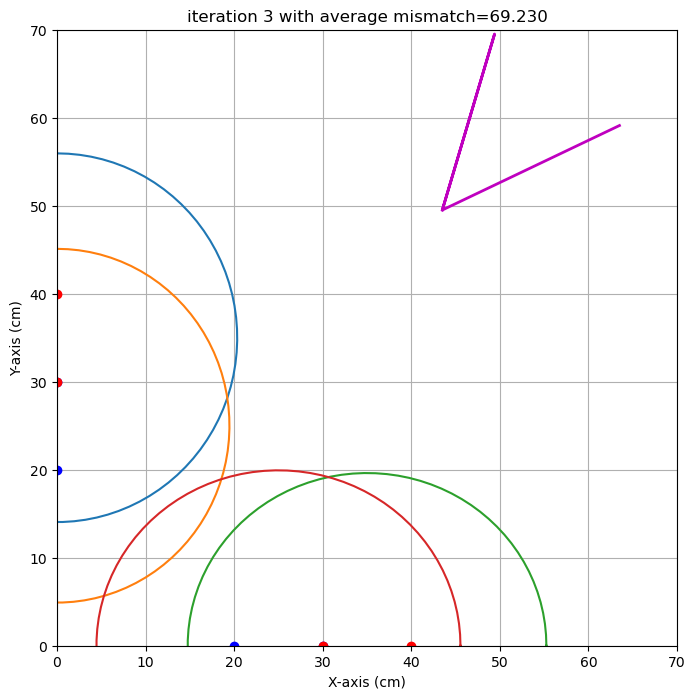

end iteration 3 with average mismatch=69.230


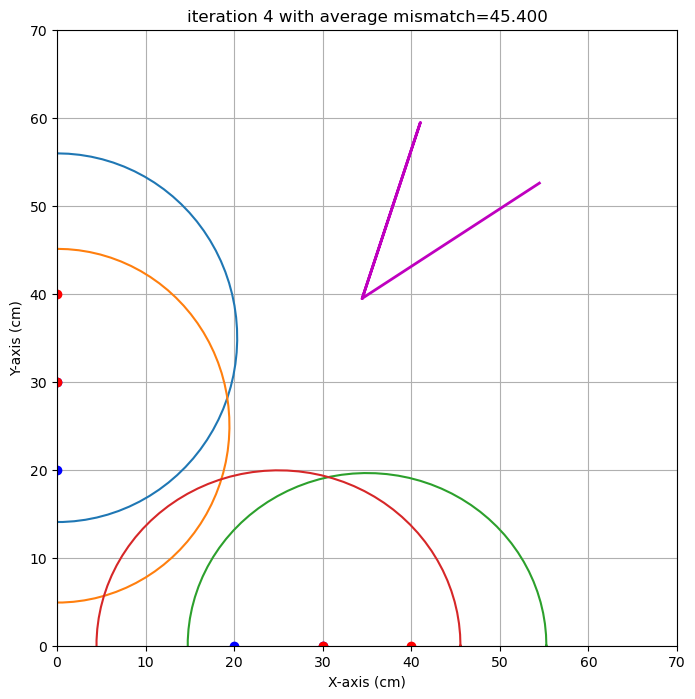

end iteration 4 with average mismatch=45.400


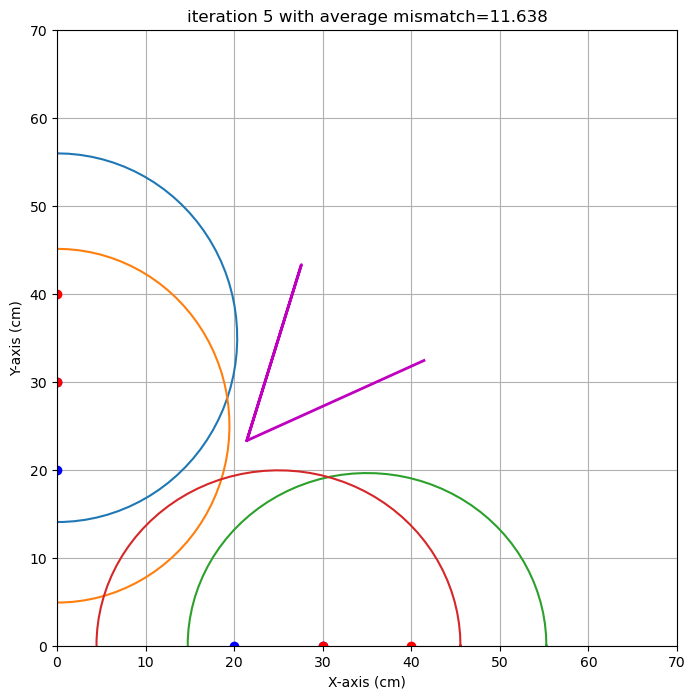

end iteration 5 with average mismatch=11.638


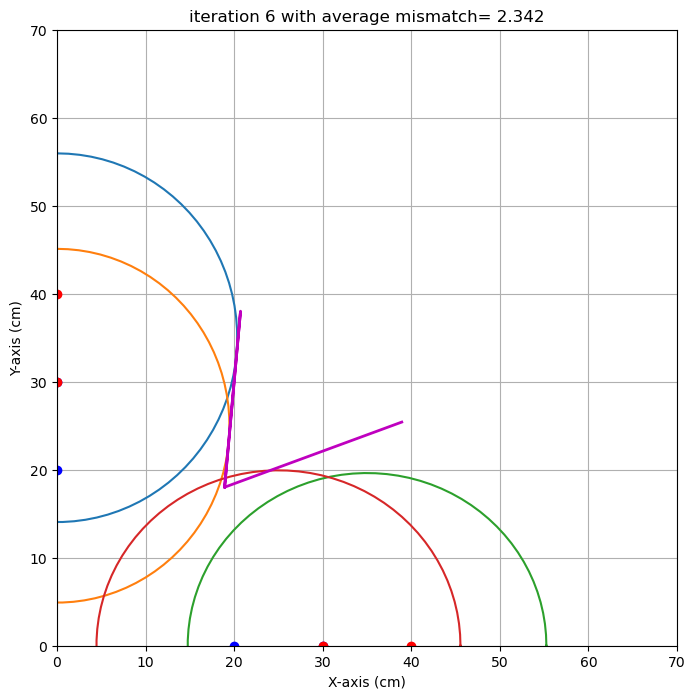

end iteration 6 with average mismatch= 2.342


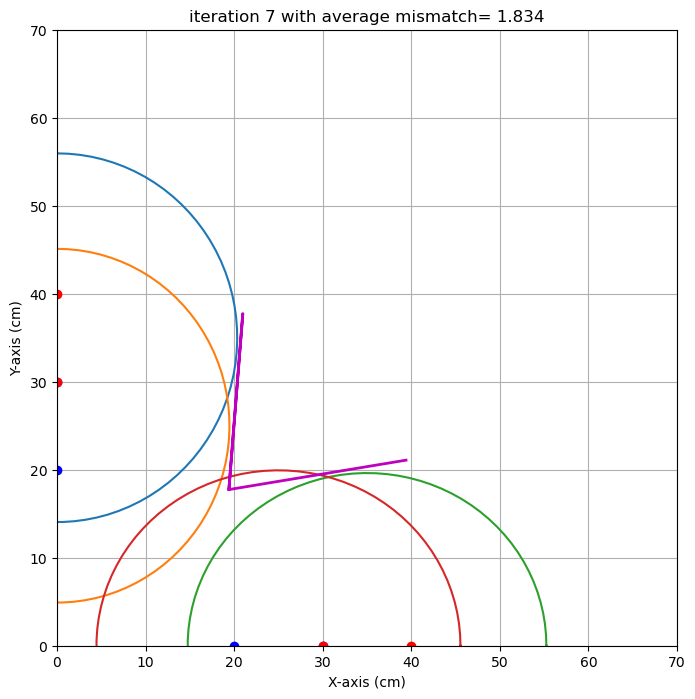

end iteration 7 with average mismatch= 1.834


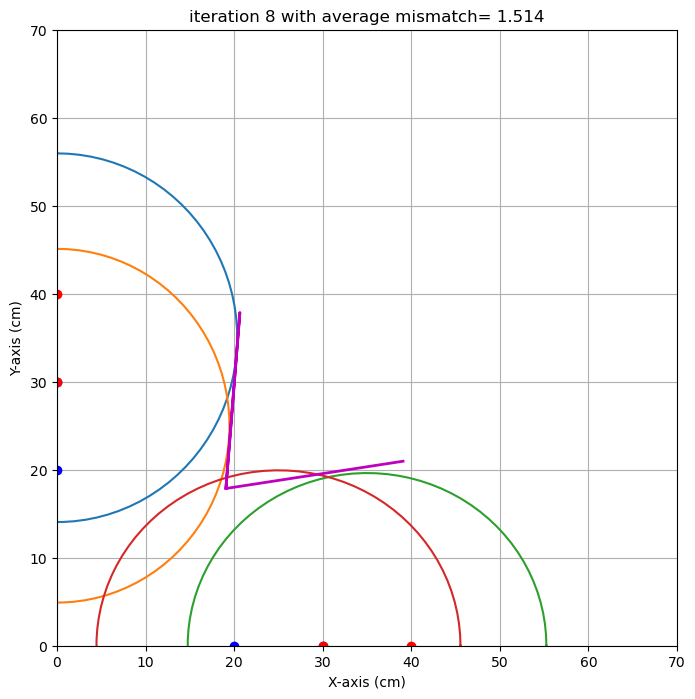

end iteration 8 with average mismatch= 1.514
end iteration 9 with average mismatch= 1.502


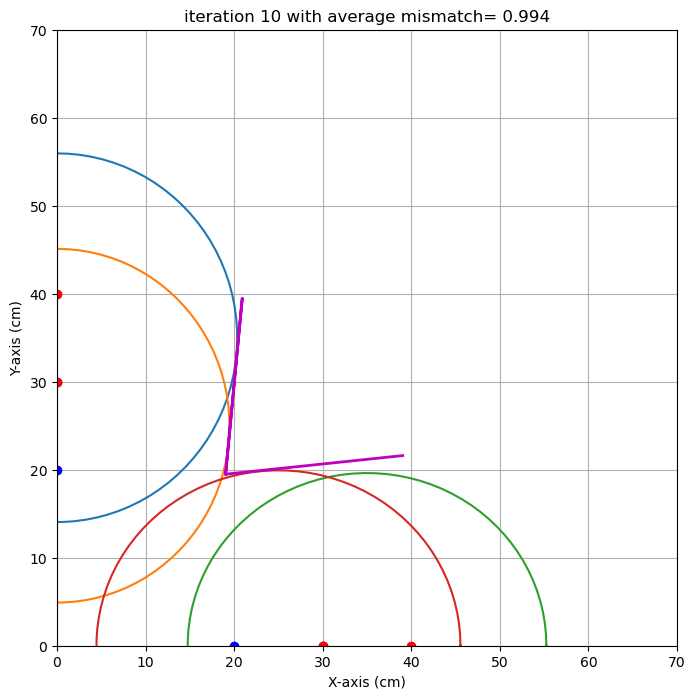

end iteration 10 with average mismatch= 0.994
end iteration 11 with average mismatch= 0.973
end iteration 12 with average mismatch= 0.969


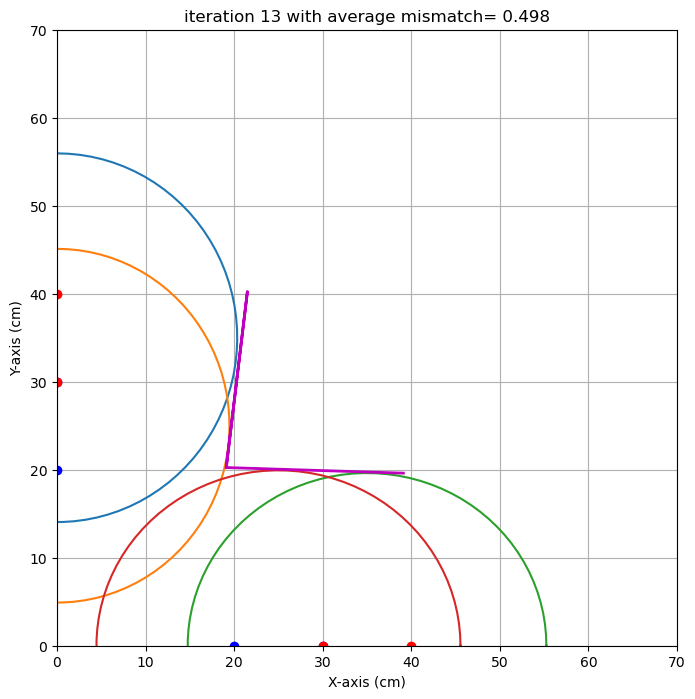

end iteration 13 with average mismatch= 0.498
end iteration 14 with average mismatch= 0.493


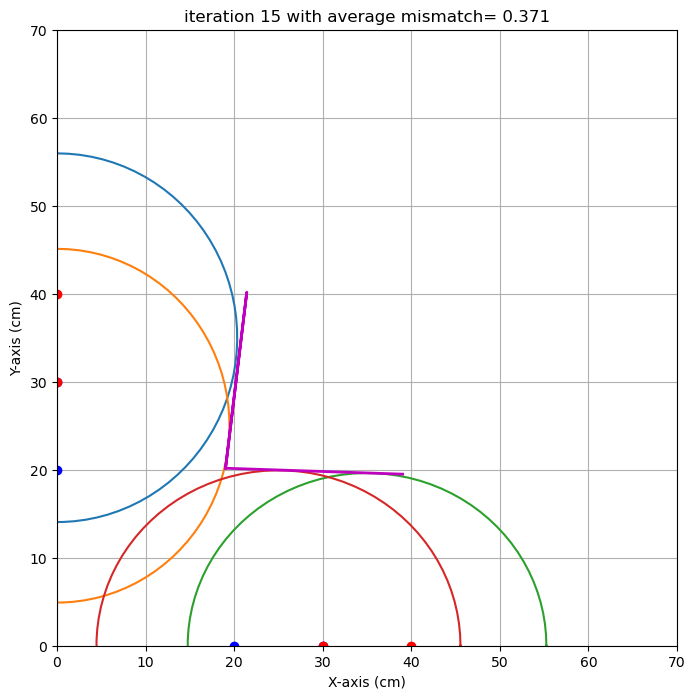

end iteration 15 with average mismatch= 0.371
end iteration 16 with average mismatch= 0.371
end iteration 17 with average mismatch= 0.371
end iteration 18 with average mismatch= 0.371
end iteration 19 with average mismatch= 0.371
end iteration 20 with average mismatch= 0.371
end iteration 21 with average mismatch= 0.371


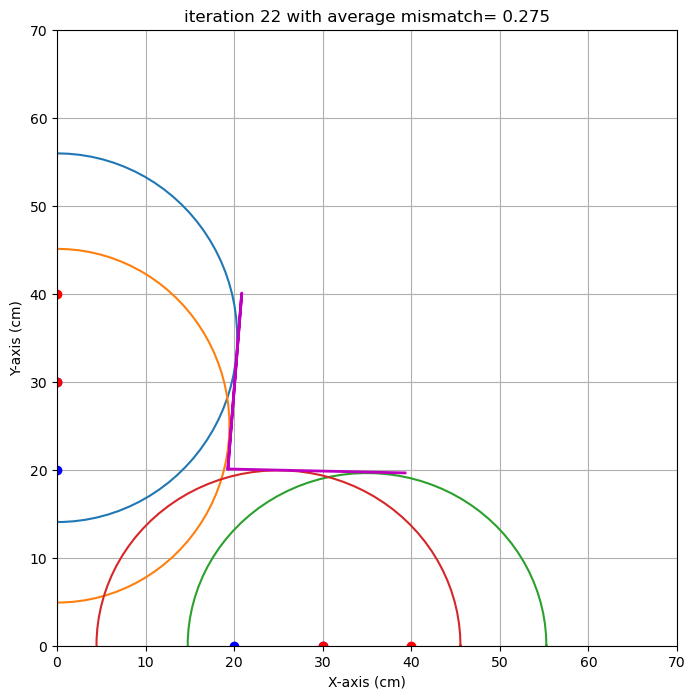

end iteration 22 with average mismatch= 0.275
end iteration 23 with average mismatch= 0.249
end iteration 24 with average mismatch= 0.248
end iteration 25 with average mismatch= 0.248
end iteration 26 with average mismatch= 0.248
end iteration 27 with average mismatch= 0.248
end iteration 28 with average mismatch= 0.248


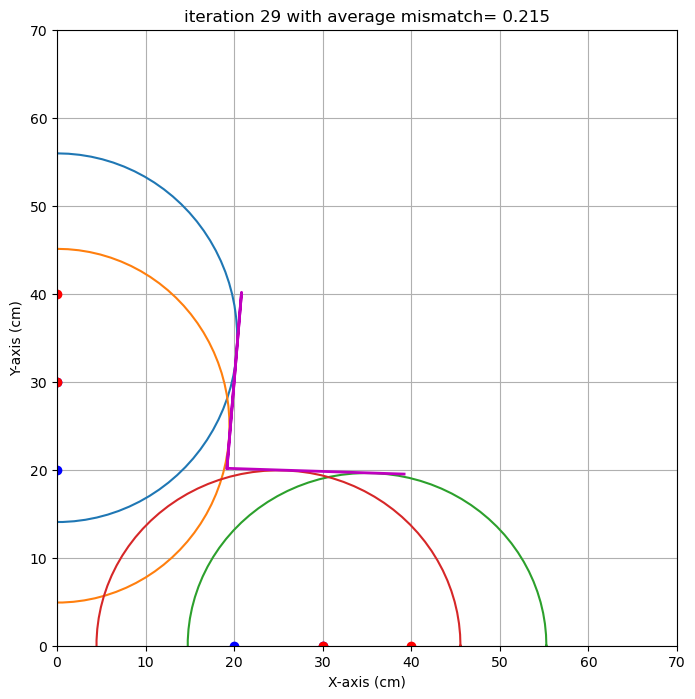

end iteration 29 with average mismatch= 0.215
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.214
###############################################################################
end of iteration  30
Best alpha=  -1.87 with uncertainty=   0.62
Best beta =   4.71 with uncertainty=   1.71
Best x0   =  19.19 with uncertainty=   0.14
Best y0   =  20.16 with uncertainty=   0.09
###############################################################################


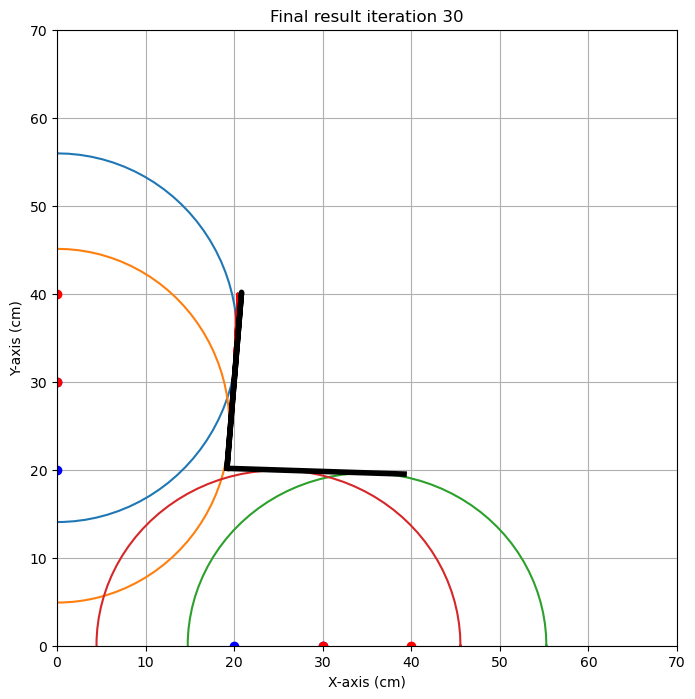

In [4]:
# Vul onderstaande matrixen aan met jullie meetgegevens.
# De getallen 1.0, 2.0, 3.0, 4.0, 5.0, 6.0 en 7.0 moet je door je eigen metingen (in cm!) vervangen.
# Let op dat de meting een totale afstand die het geluid afgelegd heeft moet zijn.

# Als je ongeldige metingen hebt (denk aan het college!), zet ze dan wel in het dataframe hieronder,
# maar gebruik een '#' om de regel uit te commenteren, zoals we bij de laatste meting voorgedaan hebben.

                
dataSanityCheck = pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,40,0,30,41.9],
    [0,30,0,20,40.2],
    #[0,10,0,20,nvt],ongeldig
    [40,0,30,0,40.5],
    [30,0,20,0,41.1],
    #[10,0,20,0,48.2],
    #[10,0,0,10,nvt]ongeldig    
    ])

resultaatSanityCheck = imagingDEF.imagingDEF(dataSanityCheck)

In [5]:
# Run deze cel om jullie resultaten te kunnen zien.
txt='x0: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
txt = txt + 'y0: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
txt = txt + 'alpha: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
txt = txt + 'beta: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
print(txt.format(x0=resultaatSanityCheck['x0'],
                 x0_eps=resultaatSanityCheck['x0_eps'],
                 y0=resultaatSanityCheck['y0'],
                 y0_eps=resultaatSanityCheck['y0_eps'],
                 alpha=resultaatSanityCheck['alpha'],
                 alpha_eps=resultaatSanityCheck['alpha_eps'],
                 beta=resultaatSanityCheck['beta'],
                 beta_eps=resultaatSanityCheck['beta_eps']))

x0: 19.2 cm met een standaardafwijking van 0.1 cm 
y0: 20.2 cm met een standaardafwijking van 0.1 cm 
alpha: -1.9 graden met een standaardafwijking van 0.6 graad 
beta: 4.7 graden met een standaardafwijking van 1.7 graad 



## Opdracht 5: Iteratie 0

#### algoritme [Nynke]
<img src="AlgoritmeN1.png" width="400">
<img src="AlgoritmeN2.png" width="400">

#### algoritme [Wobbe]

<img src="AlgoritmeW.png" width="400">

#### algoritme [Jesse]

<img src="AlgoritmeJ.png" width="400">

In [6]:
# Voeg hier eventueel code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 6: Test iteratie 0.

In [7]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen posities van het reflecterende papier
targets = {'x0':  20,
           'y0': 35.5,
           'alpha' : 10,
           'beta' : 20,
           }

# Vul onderstaande matrixen aan met je gemeten meetgegevens. Als je twee algoritmes test, haal dan het hele blok
# bij 'naam3' weg. Zorg natuurlijk dat de arrays en structures netjes afsluiten met ), ] of } op de juiste plekken.

data ={'Wobbe' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [0,30,0,20,71.95],
    [0,40,0,30,72.8],
    [0,50,0,40,74.2],
    #[0,60,0,50,ongeldig]
    #[30,0,20,0,ongeldig]
    [40,0,30,0,47.0],
    [50,0,40,0,52.1],
    [60,0,50,0,53.1],
    [55,0,40,0,49.6],
    [45,0,35,0,50.1]
    ]),
       'Jesse' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[0,30,0,40,ongeldig],
    [0,40,0,50,47.6],
    [30,0,40,0,73.56]
    ])
      }

## Opdracht 7: Evaluatie.

Wobbe
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  30   0  20  71.95
1   0  40   0  30  72.80
2   0  50   0  40  74.20
3  40   0  30   0  47.00
4  50   0  40   0  52.10
5  60   0  50   0  53.10
6  55   0  40   0  49.60
7  45   0  35   0  50.10


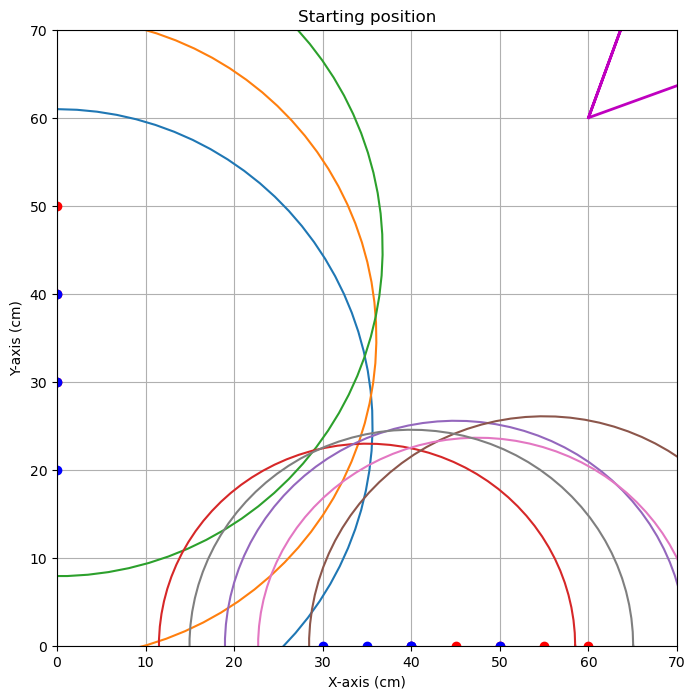


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=76.027


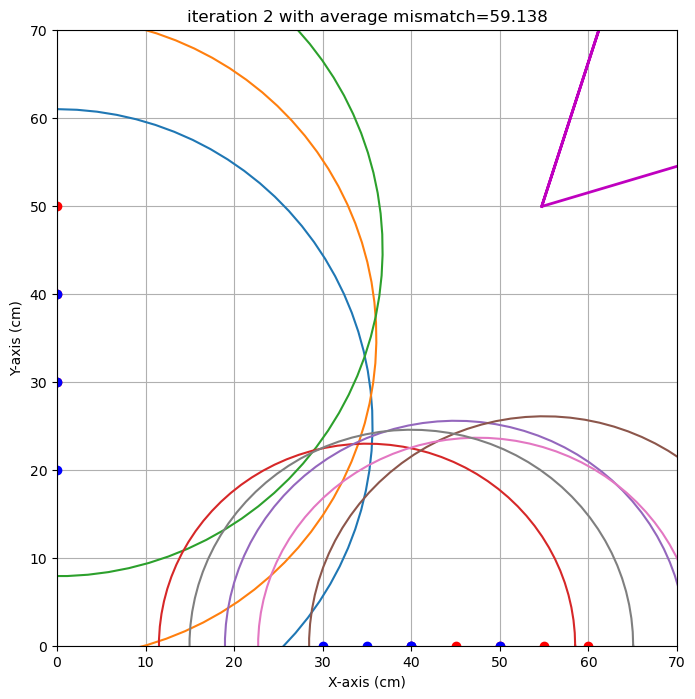

end iteration 2 with average mismatch=59.138


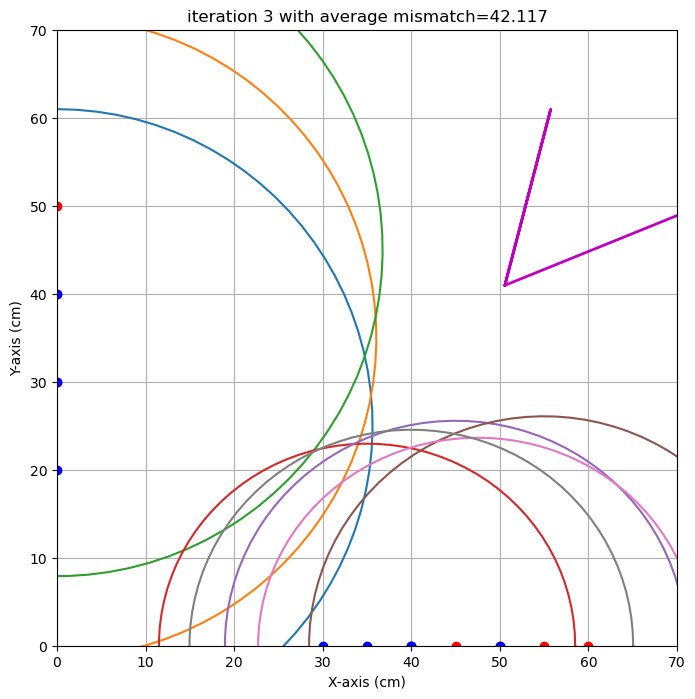

end iteration 3 with average mismatch=42.117


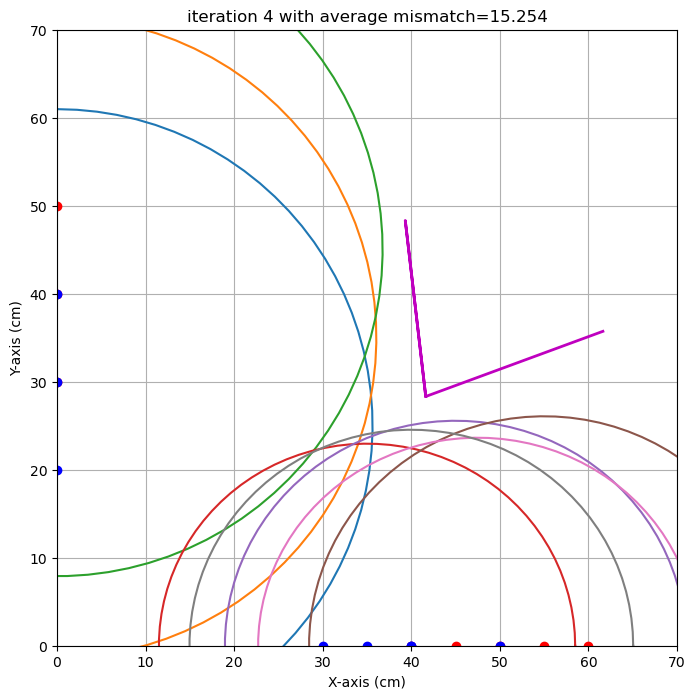

end iteration 4 with average mismatch=15.254


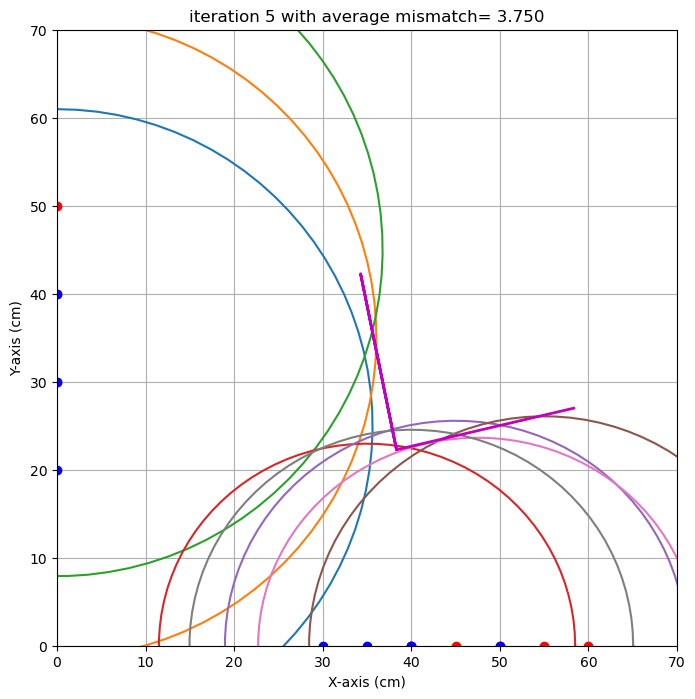

end iteration 5 with average mismatch= 3.750


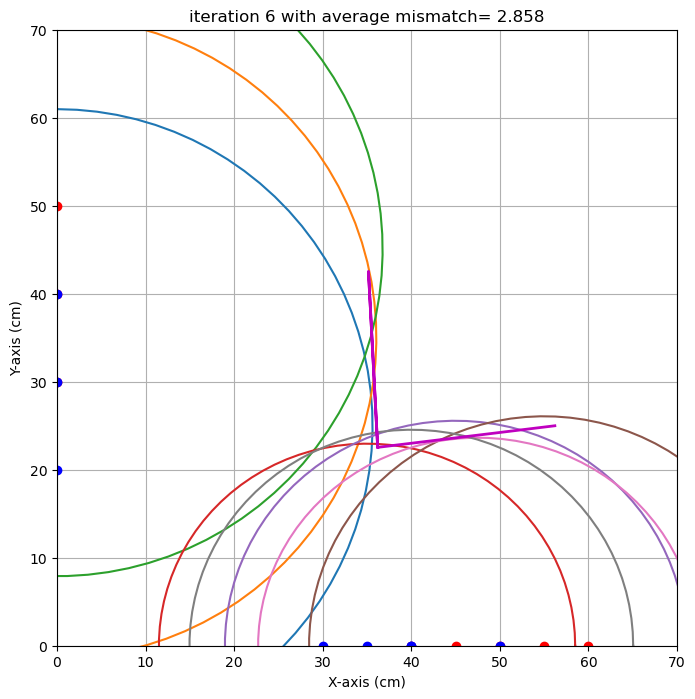

end iteration 6 with average mismatch= 2.858


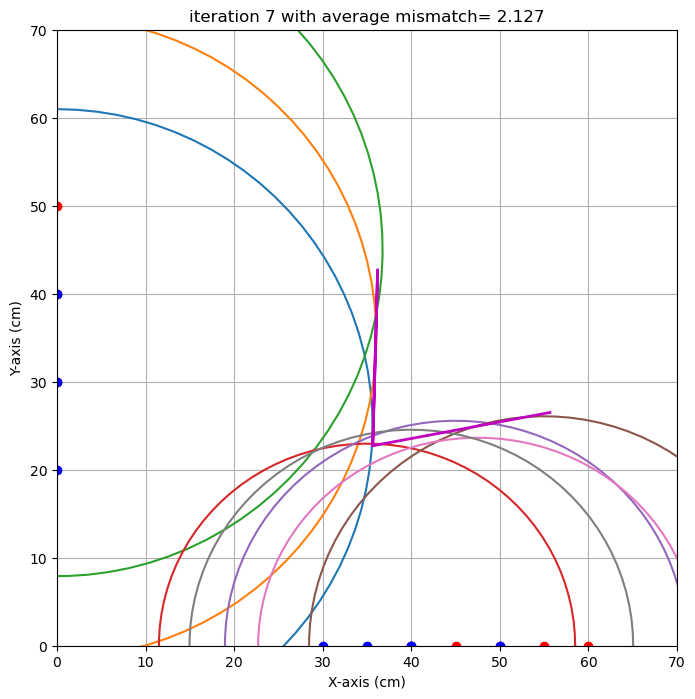

end iteration 7 with average mismatch= 2.127
end iteration 8 with average mismatch= 2.086
end iteration 9 with average mismatch= 2.001
end iteration 10 with average mismatch= 2.001
end iteration 11 with average mismatch= 2.001
end iteration 12 with average mismatch= 2.001
end iteration 13 with average mismatch= 2.001
end iteration 14 with average mismatch= 2.001
end iteration 15 with average mismatch= 2.001
end iteration 16 with average mismatch= 1.990
end iteration 17 with average mismatch= 1.940
end iteration 18 with average mismatch= 1.940
end iteration 19 with average mismatch= 1.940
end iteration 20 with average mismatch= 1.940
end iteration 21 with average mismatch= 1.940
end iteration 22 with average mismatch= 1.940
end iteration 23 with average mismatch= 1.940
end iteration 24 with average mismatch= 1.940
end iteration 25 with average mismatch= 1.940
end iteration 26 with average mismatch= 1.940
end iteration 27 with average mismatch= 1.940
end iteration 28 with average mismatc

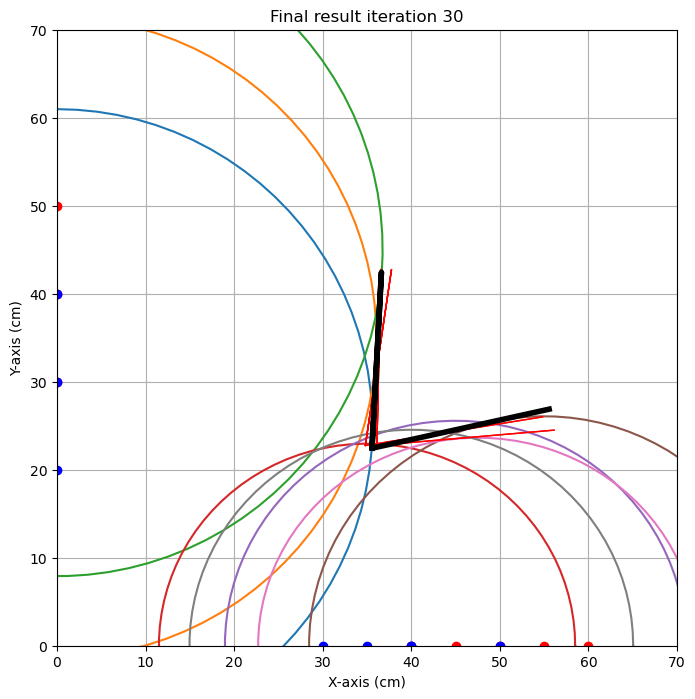

{'alpha': np.float64(12.510880062815131), 'alpha_eps': np.float64(7.5600957905856365), 'beta': np.float64(3.052143104628936), 'beta_eps': np.float64(5.350196967496187), 'x0': np.float64(35.55998760815042), 'x0_eps': np.float64(0.7503393838080825), 'y0': np.float64(22.443608261718623), 'y0_eps': np.float64(0.32083851488278015)}
Jesse
Running the imaging algorithm with the following data:
   xs  ys  xr  yr      R
0   0  40   0  50  47.60
1  30   0  40   0  73.56


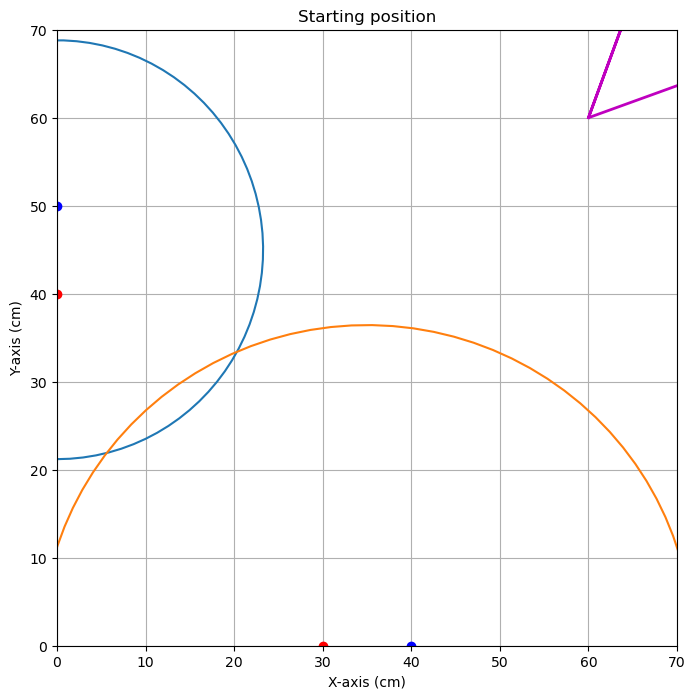


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=73.026


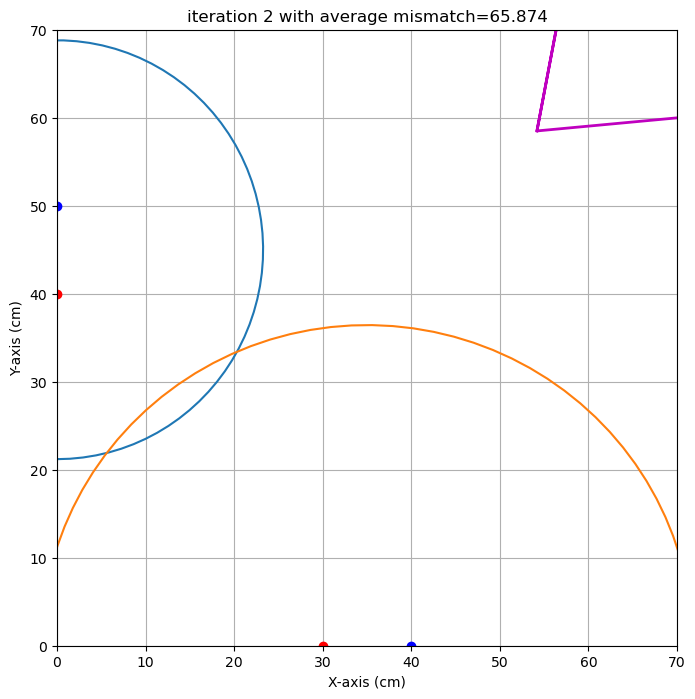

end iteration 2 with average mismatch=65.874


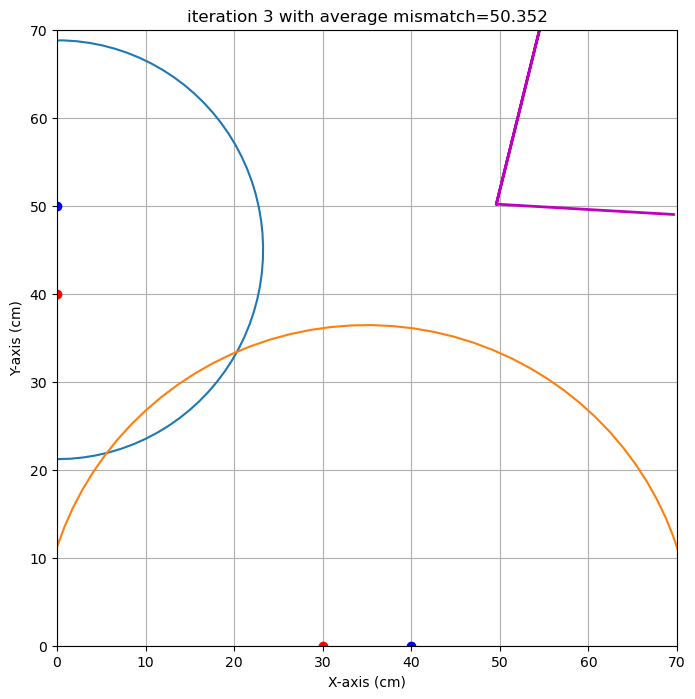

end iteration 3 with average mismatch=50.352


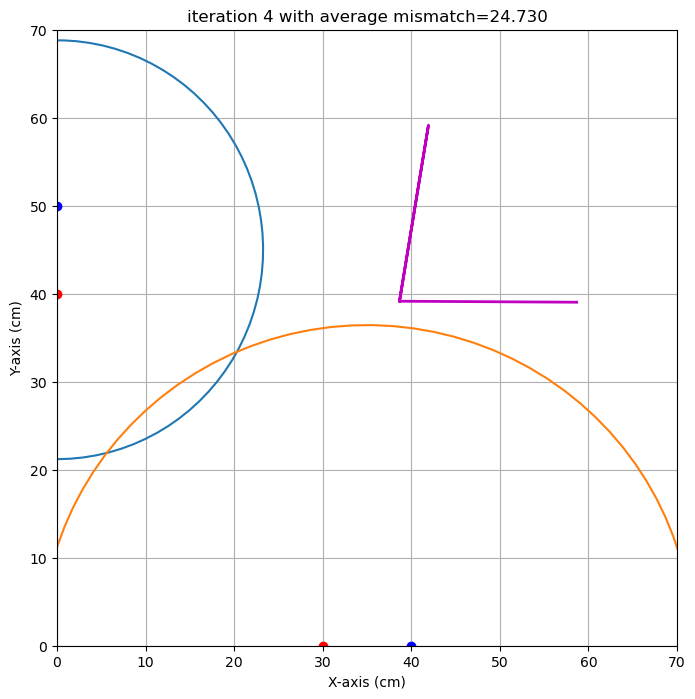

end iteration 4 with average mismatch=24.730


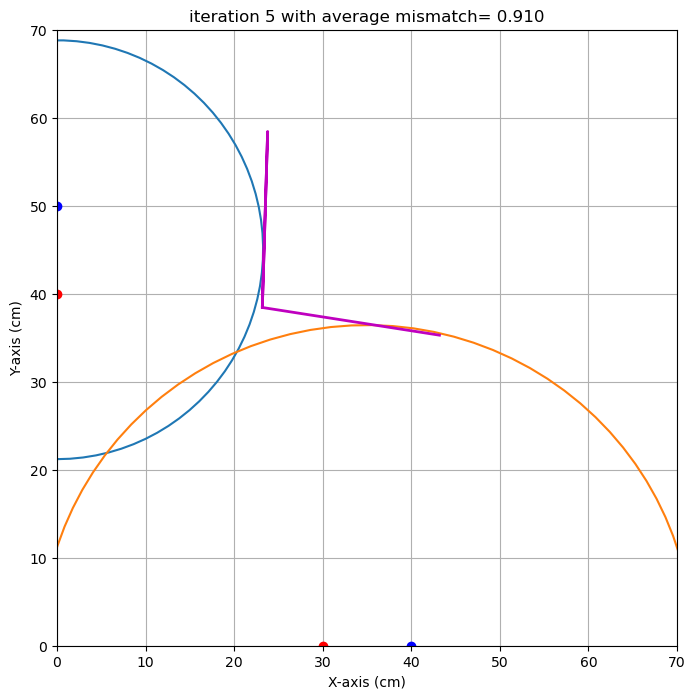

end iteration 5 with average mismatch= 0.910


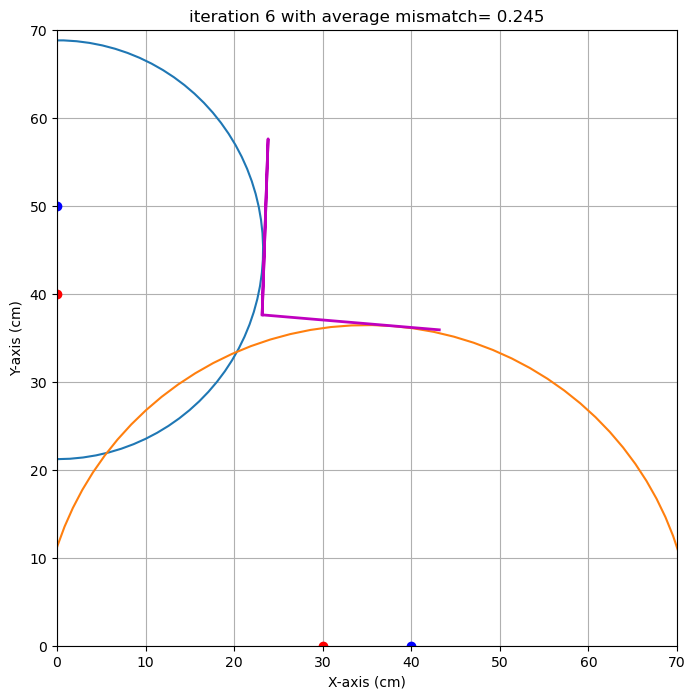

end iteration 6 with average mismatch= 0.245


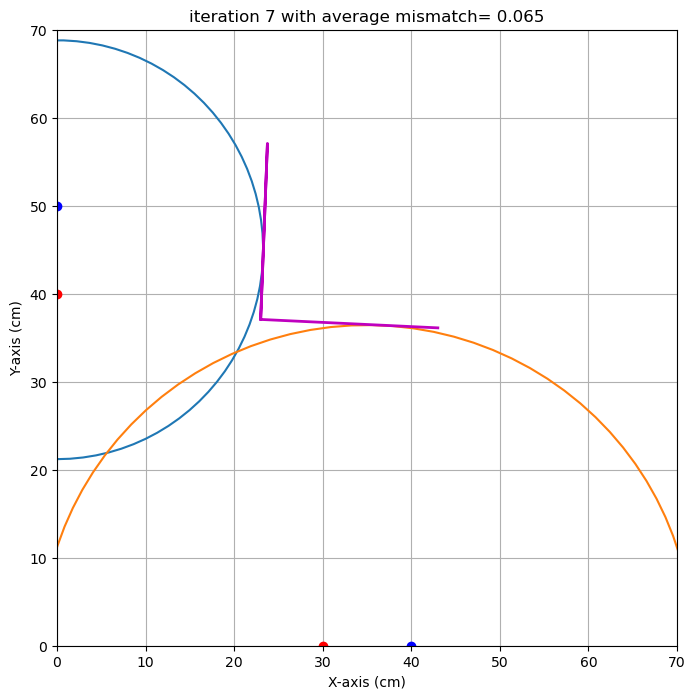

end iteration 7 with average mismatch= 0.065


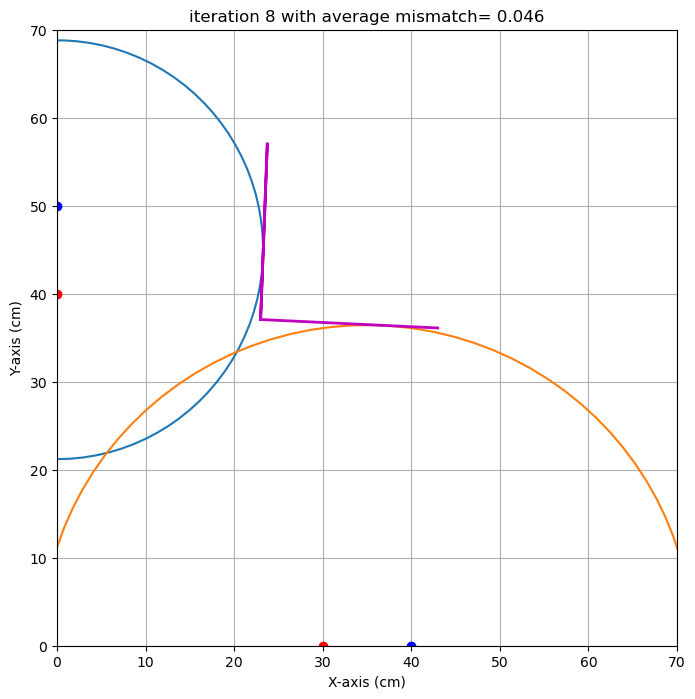

end iteration 8 with average mismatch= 0.046
end iteration 9 with average mismatch= 0.044
end iteration 10 with average mismatch= 0.043
end iteration 11 with average mismatch= 0.043
end iteration 12 with average mismatch= 0.043
end iteration 13 with average mismatch= 0.043
end iteration 14 with average mismatch= 0.043
end iteration 15 with average mismatch= 0.043
end iteration 16 with average mismatch= 0.043
end iteration 17 with average mismatch= 0.043
end iteration 18 with average mismatch= 0.043
end iteration 19 with average mismatch= 0.043
end iteration 20 with average mismatch= 0.043
end iteration 21 with average mismatch= 0.043
end iteration 22 with average mismatch= 0.043
end iteration 23 with average mismatch= 0.043
end iteration 24 with average mismatch= 0.043
end iteration 25 with average mismatch= 0.043
end iteration 26 with average mismatch= 0.043
end iteration 27 with average mismatch= 0.043
end iteration 28 with average mismatch= 0.043
end iteration 29 with average mismat

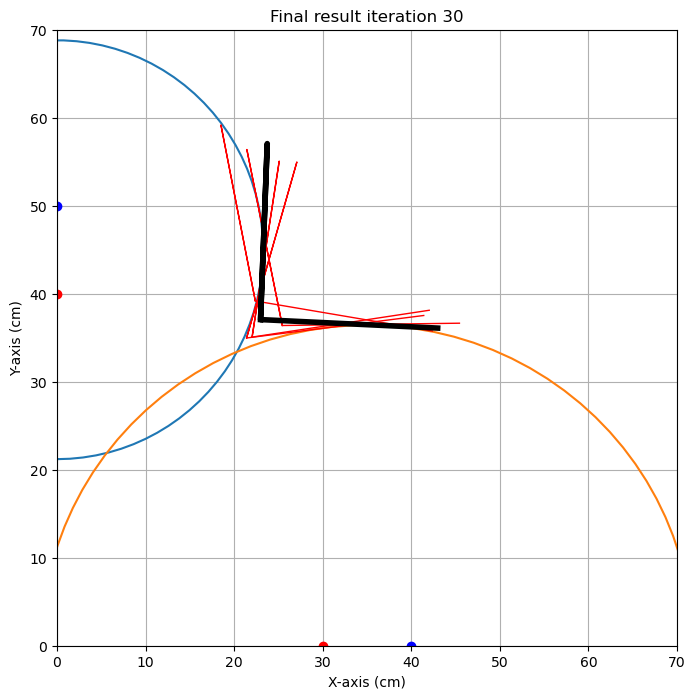

{'alpha': np.float64(-2.7586861561015543), 'alpha_eps': np.float64(11.431360948815751), 'beta': np.float64(2.1730711888441263), 'beta_eps': np.float64(13.673891588460073), 'x0': np.float64(22.976126277068445), 'x0_eps': np.float64(2.4568424866166865), 'y0': np.float64(37.06051412412338), 'y0_eps': np.float64(2.116160739403959)}


In [8]:
# Hier runnen we het imaging algoritme:
resultaat = dict()

for studentName in studentNames:
    print(studentName)
    resultaat[studentName] = imagingDEF.imagingDEF(data[studentName])
    print(resultaat[studentName])

In [9]:
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for studentName in studentNames:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = studentName,
                     x0Target=targets['x0'],
                     x0=resultaat[studentName]['x0'],
                     x0_eps=resultaat[studentName]['x0_eps'],
                     y0Target=targets['y0'],
                     y0=resultaat[studentName]['y0'],
                     y0_eps=resultaat[studentName]['y0_eps'],
                     alphaTarget=targets['alpha'],
                     alpha=resultaat[studentName]['alpha'],
                     alpha_eps=resultaat[studentName]['alpha_eps'],
                     betaTarget=targets['beta'],
                     beta=resultaat[studentName]['beta'],
                     beta_eps=resultaat[studentName]['beta_eps']))

Wobbe 
x0 target is : 20.0. Gevonden waarde: 35.6 cm met een standaardafwijking van 0.8 cm 
y0 target is : 35.5. Gevonden waarde: 22.4 cm met een standaardafwijking van 0.3 cm 
alpha target is : 10.0. Gevonden waarde: 12.5 graden met een standaardafwijking van 7.6 graad 
beta target is : 20.0. Gevonden waarde: 3.1 graden met een standaardafwijking van 5.4 graad 

Jesse 
x0 target is : 20.0. Gevonden waarde: 23.0 cm met een standaardafwijking van 2.5 cm 
y0 target is : 35.5. Gevonden waarde: 37.1 cm met een standaardafwijking van 2.1 cm 
alpha target is : 10.0. Gevonden waarde: -2.8 graden met een standaardafwijking van 11.4 graad 
beta target is : 20.0. Gevonden waarde: 2.2 graden met een standaardafwijking van 13.7 graad 



## Opdracht 8: Iteratie1+. 14:25
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Iteratie2.png)

Veranderingen van iteratie 2 -> Afstand tussen bron en ontvanger vergroot, zodat er een grotere kans is op geldige waarde (door hoek) en y-as keuze onafhankelijk van uitkomst x-as gehouden.

In [10]:
# Voeg hier eventueel (nieuwe) code toe die je nodig hebt om je algoritme uit te voeren. Dit is optioneel!

## Opdracht 9: Iteratie 1+ meeting en test

locatie 1
Running the imaging algorithm with the following data:
   xs    ys  xr    yr     R
0  30   0.0  40   0.0  95.2
1  35   0.0  45   0.0  90.6
2   0  47.6   0  57.6  73.5
3   0  52.6   0  62.6  73.6
4   0  42.6   0  52.6  76.6


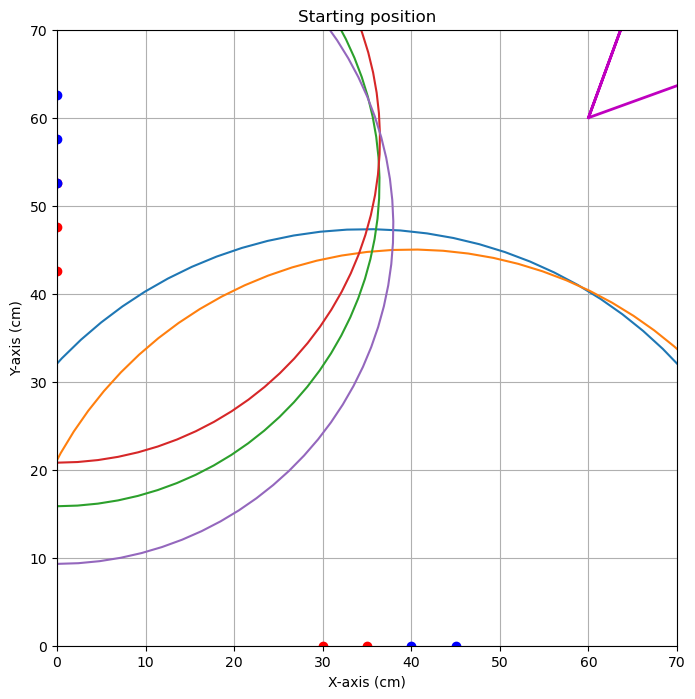


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=47.673


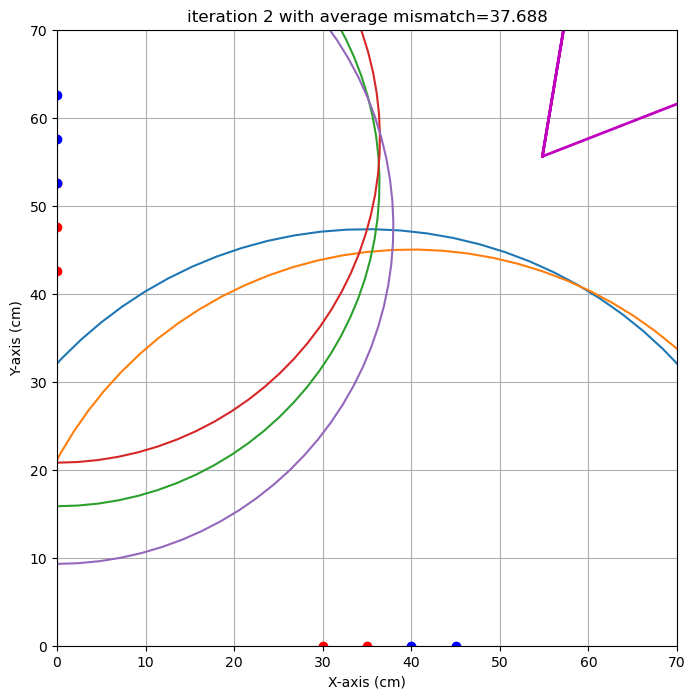

end iteration 2 with average mismatch=37.688


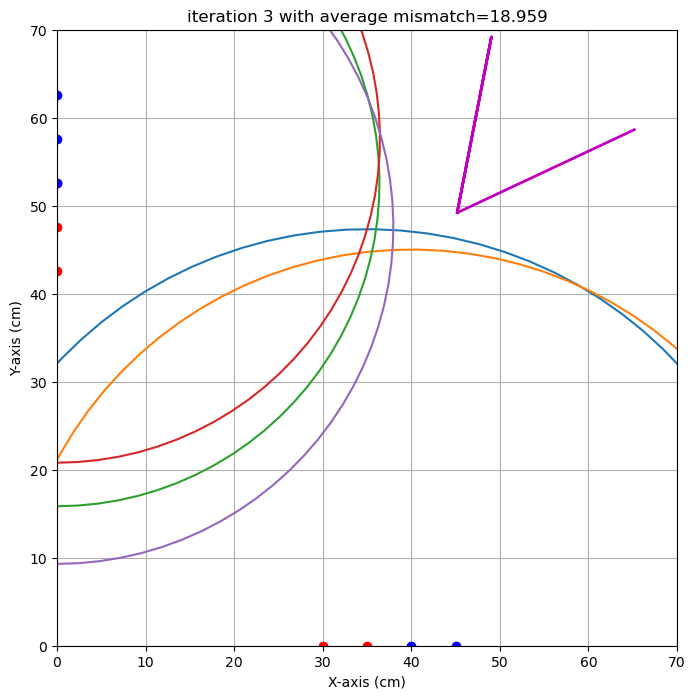

end iteration 3 with average mismatch=18.959


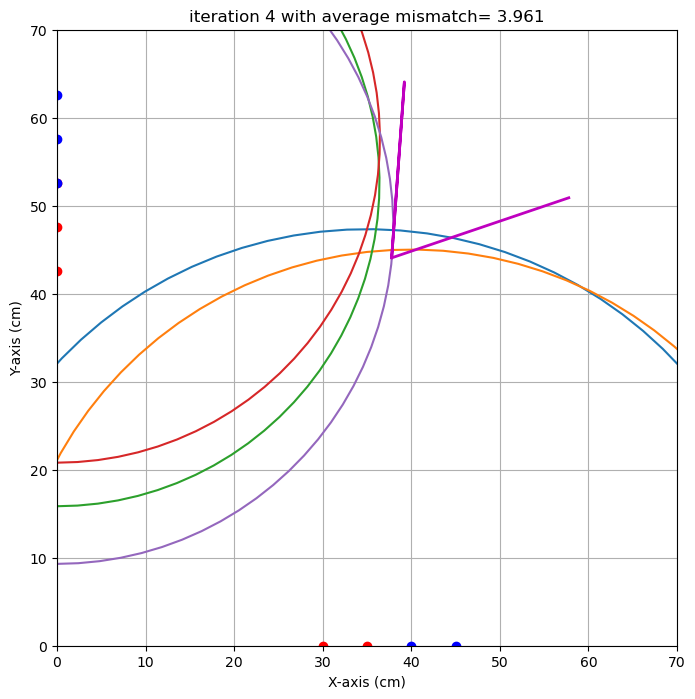

end iteration 4 with average mismatch= 3.961


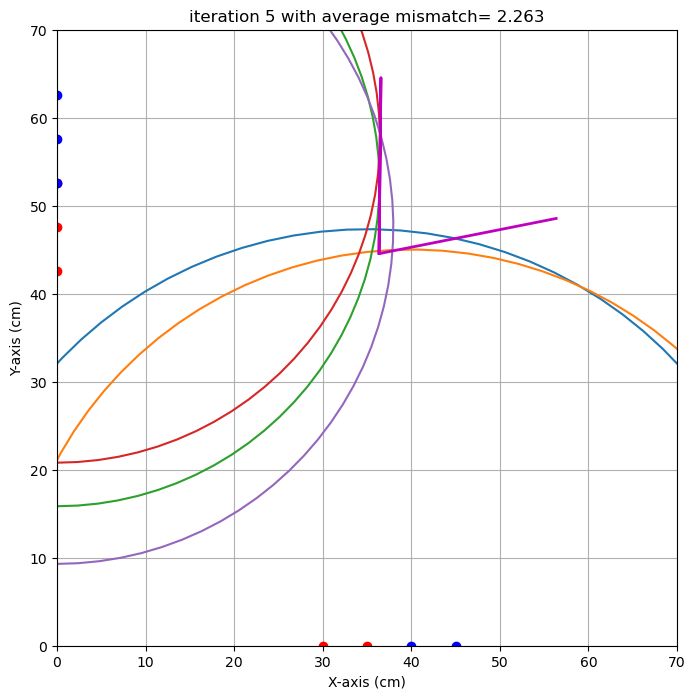

end iteration 5 with average mismatch= 2.263


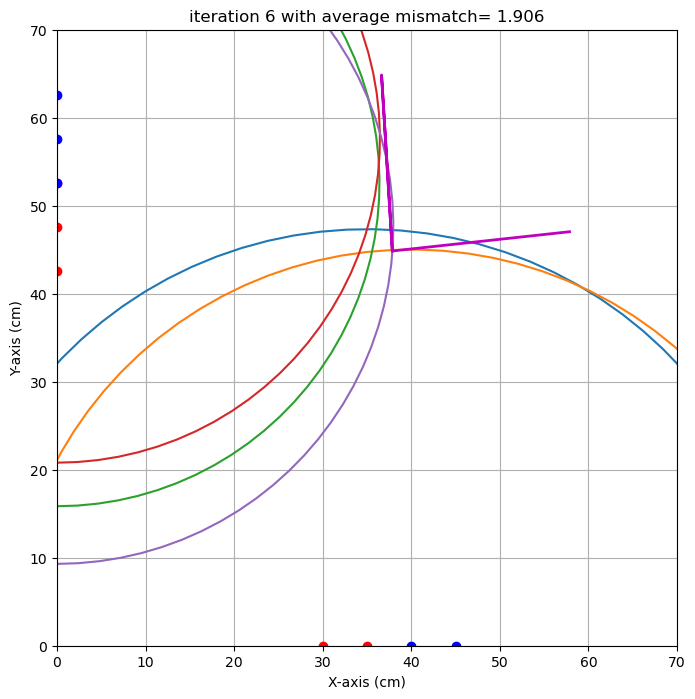

end iteration 6 with average mismatch= 1.906


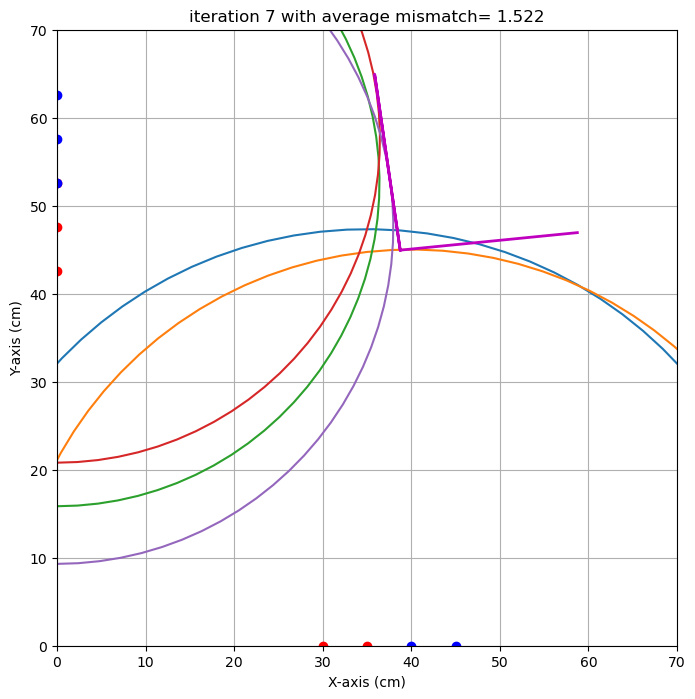

end iteration 7 with average mismatch= 1.522
end iteration 8 with average mismatch= 1.438
end iteration 9 with average mismatch= 1.434
end iteration 10 with average mismatch= 1.324
end iteration 11 with average mismatch= 1.260


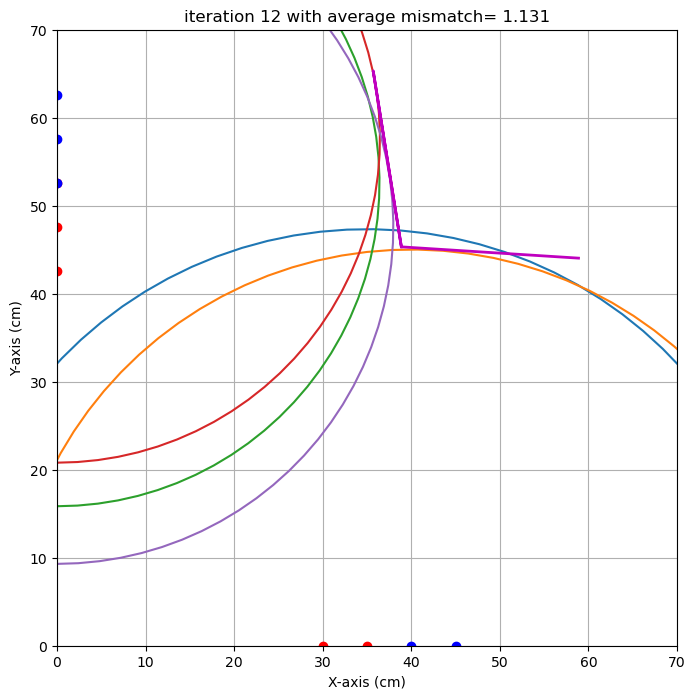

end iteration 12 with average mismatch= 1.131
end iteration 13 with average mismatch= 1.131
end iteration 14 with average mismatch= 1.131
end iteration 15 with average mismatch= 1.131
end iteration 16 with average mismatch= 1.128
end iteration 17 with average mismatch= 1.090
end iteration 18 with average mismatch= 1.074
end iteration 19 with average mismatch= 1.006
end iteration 20 with average mismatch= 1.003
end iteration 21 with average mismatch= 1.003
end iteration 22 with average mismatch= 1.003
end iteration 23 with average mismatch= 1.003
end iteration 24 with average mismatch= 1.003
end iteration 25 with average mismatch= 1.003
end iteration 26 with average mismatch= 1.003
end iteration 27 with average mismatch= 1.003
end iteration 28 with average mismatch= 1.003
end iteration 29 with average mismatch= 1.003
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 1.003
#################

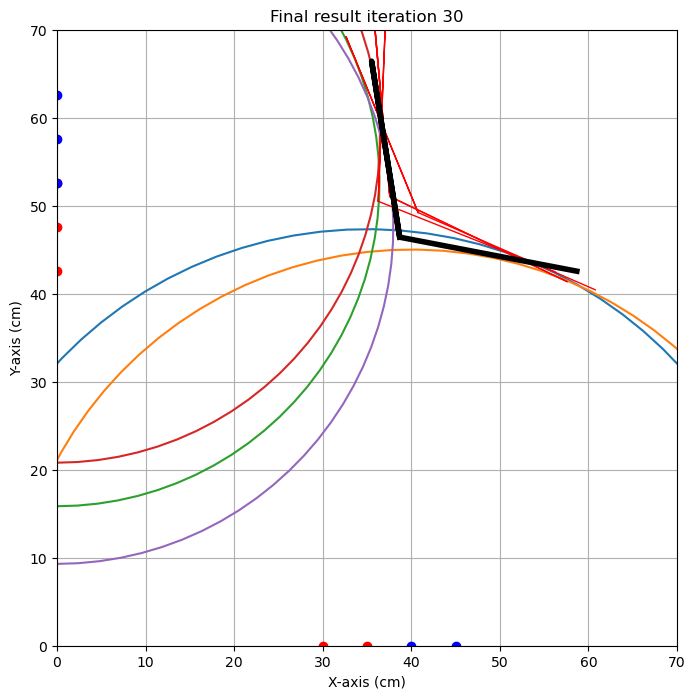

{'alpha': np.float64(-10.937286521340962), 'alpha_eps': np.float64(14.870896159710806), 'beta': np.float64(-9.005955448172879), 'beta_eps': np.float64(13.153691179958356), 'x0': np.float64(38.68662229133351), 'x0_eps': np.float64(2.4263328641151176), 'y0': np.float64(46.42515577229252), 'y0_eps': np.float64(4.626122045400642)}
locatie 2
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  40   0  60   0  85.8
1  50   0  70   0  89.1
2   0  40   0  60  75.2
3   0  50   0  70  76.8


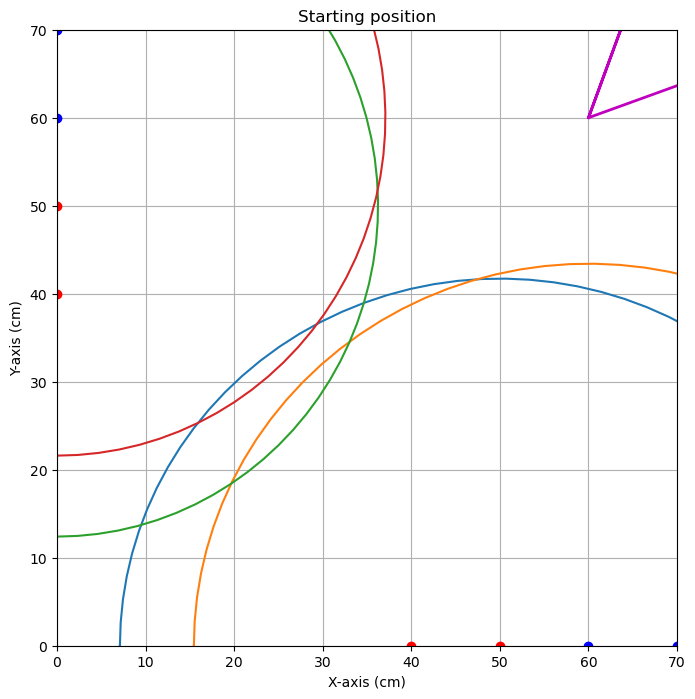


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=46.391


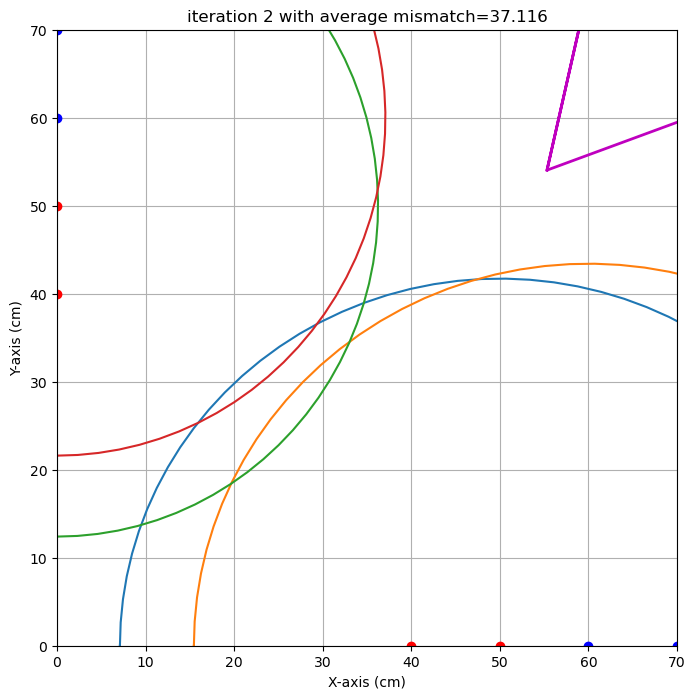

end iteration 2 with average mismatch=37.116


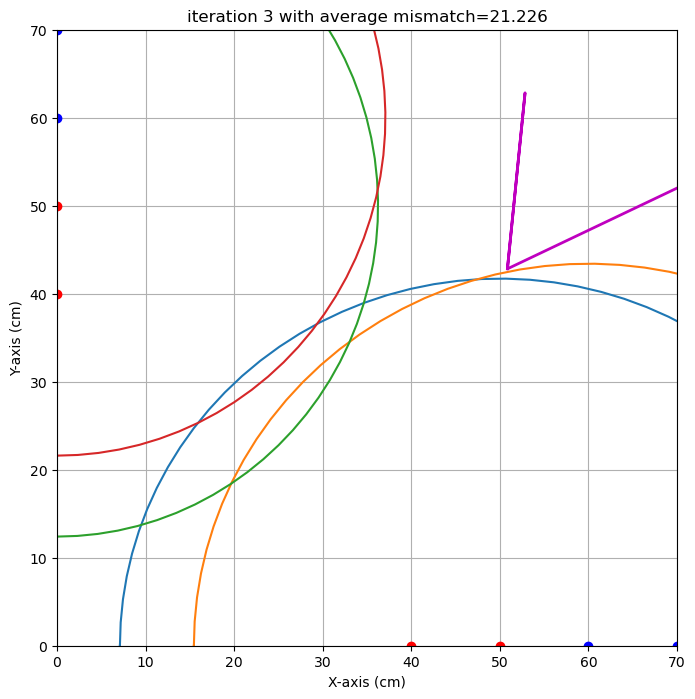

end iteration 3 with average mismatch=21.226


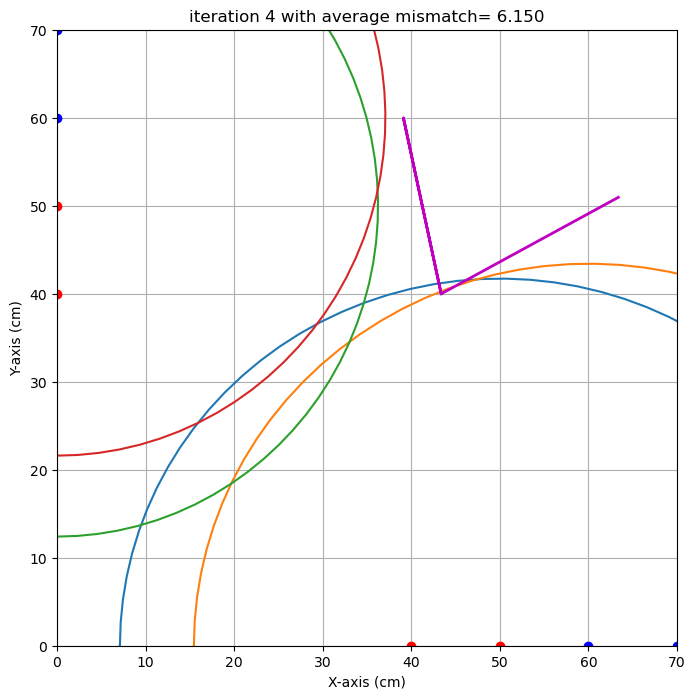

end iteration 4 with average mismatch= 6.150


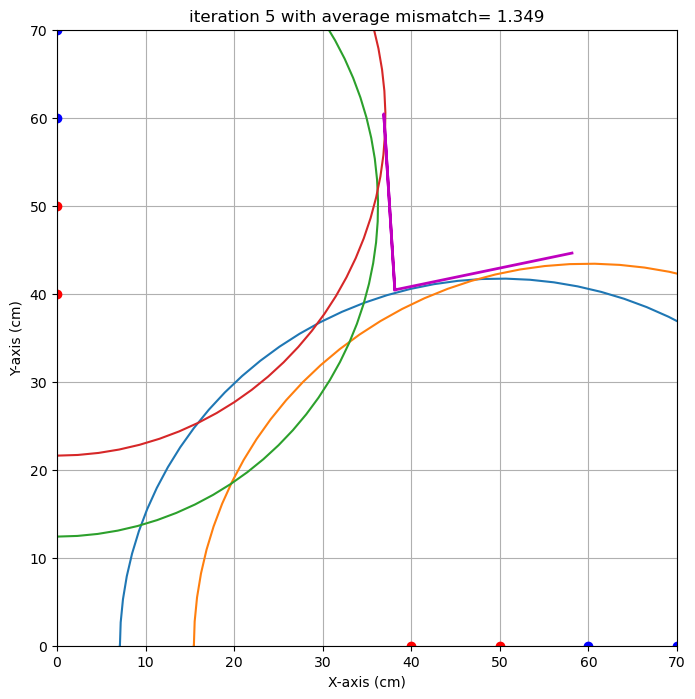

end iteration 5 with average mismatch= 1.349


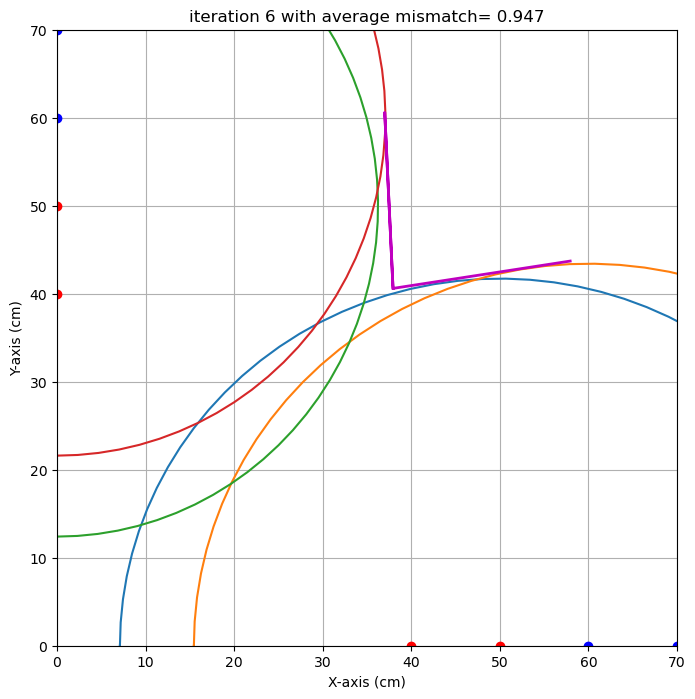

end iteration 6 with average mismatch= 0.947


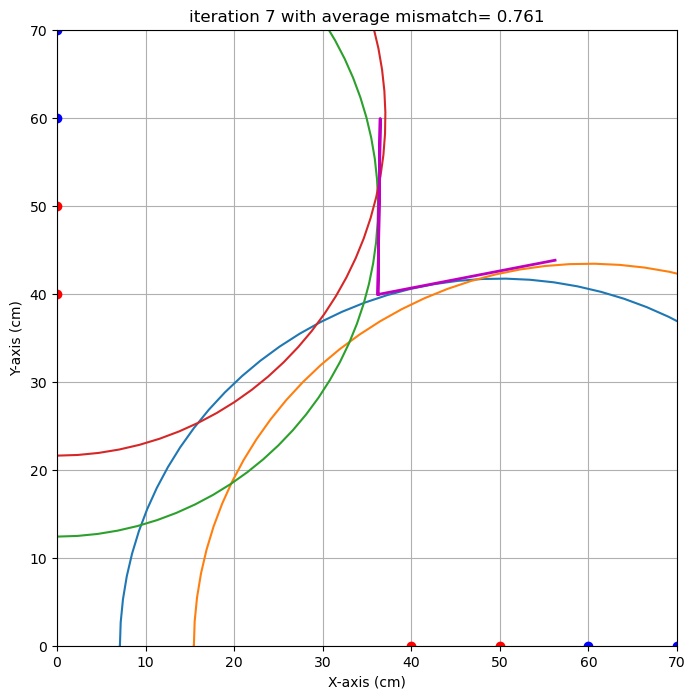

end iteration 7 with average mismatch= 0.761


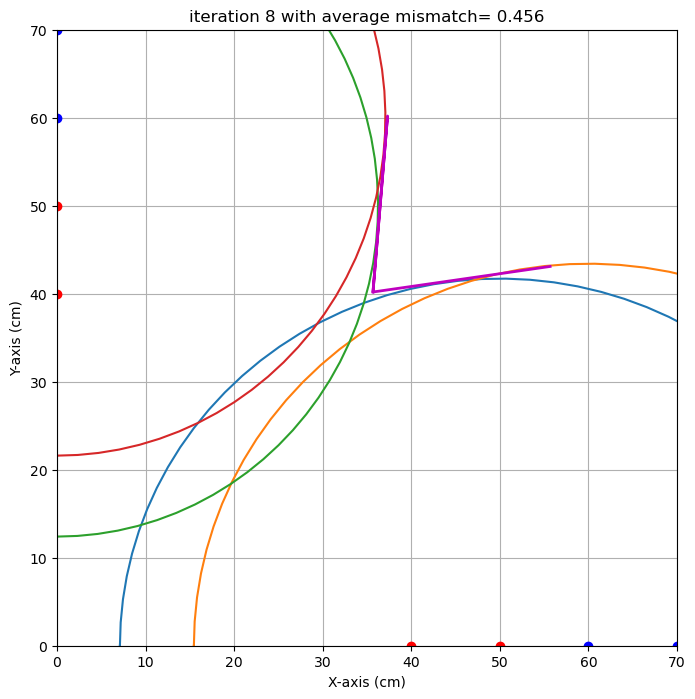

end iteration 8 with average mismatch= 0.456


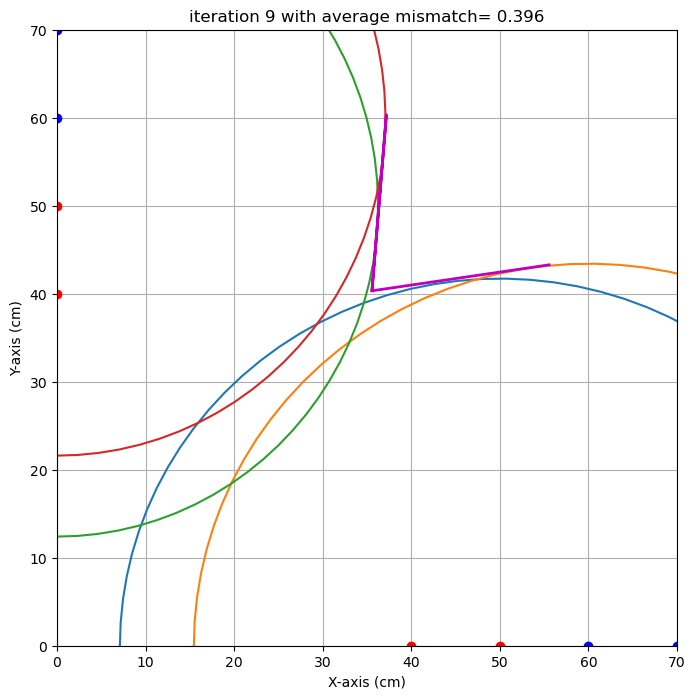

end iteration 9 with average mismatch= 0.396


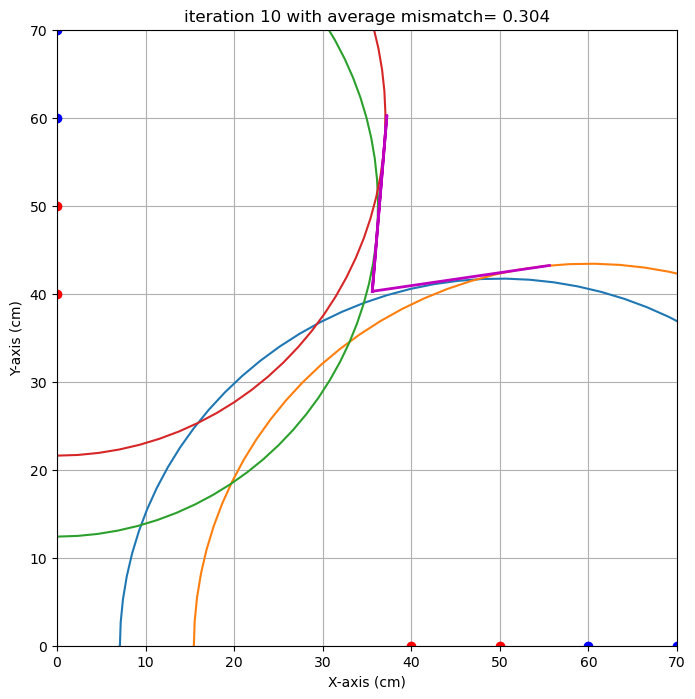

end iteration 10 with average mismatch= 0.304
end iteration 11 with average mismatch= 0.302
end iteration 12 with average mismatch= 0.302


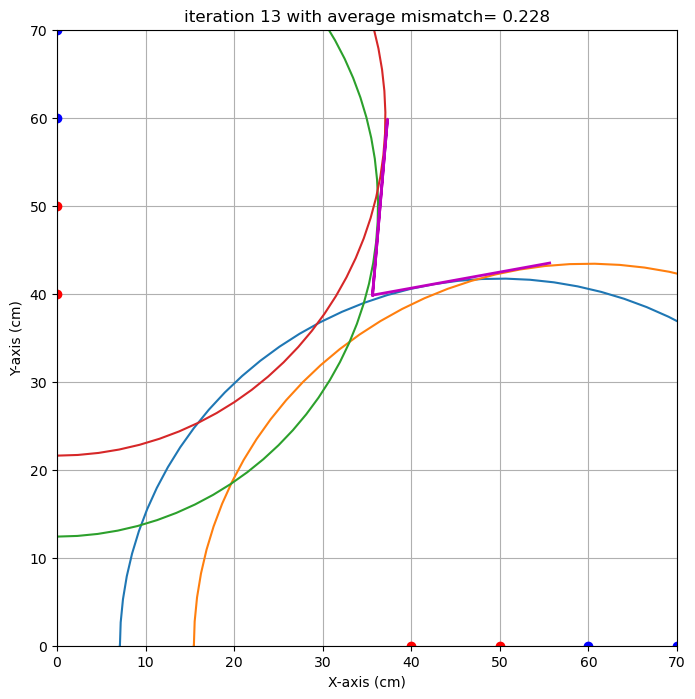

end iteration 13 with average mismatch= 0.228


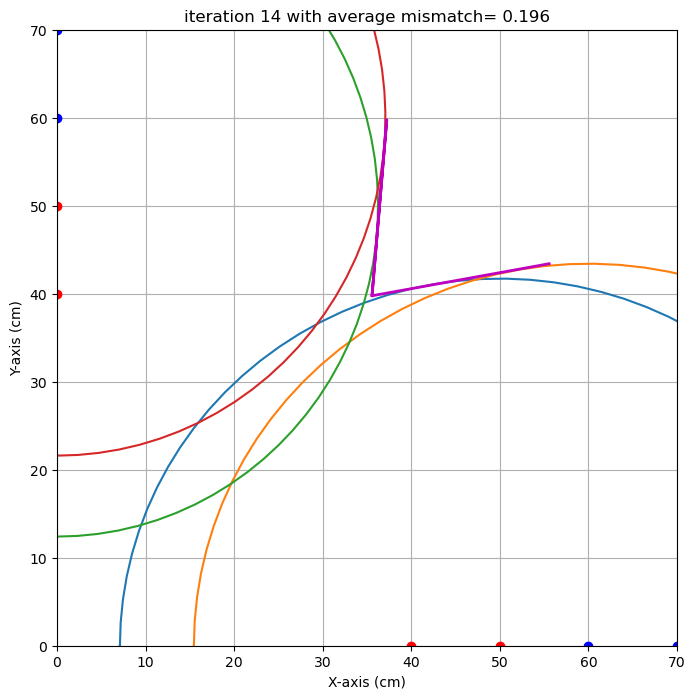

end iteration 14 with average mismatch= 0.196


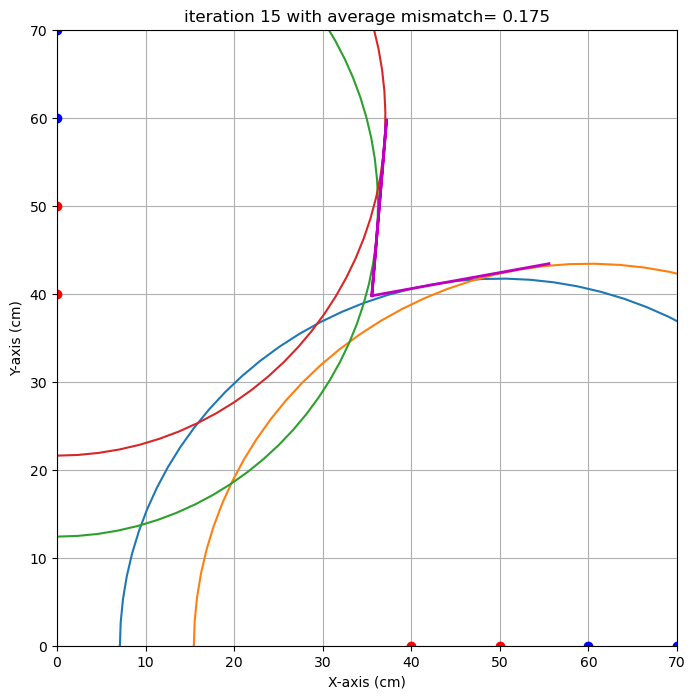

end iteration 15 with average mismatch= 0.175
end iteration 16 with average mismatch= 0.166
end iteration 17 with average mismatch= 0.166
end iteration 18 with average mismatch= 0.166
end iteration 19 with average mismatch= 0.166
end iteration 20 with average mismatch= 0.166
end iteration 21 with average mismatch= 0.166
end iteration 22 with average mismatch= 0.166
end iteration 23 with average mismatch= 0.166
end iteration 24 with average mismatch= 0.166
end iteration 25 with average mismatch= 0.166
end iteration 26 with average mismatch= 0.166
end iteration 27 with average mismatch= 0.166
end iteration 28 with average mismatch= 0.166
end iteration 29 with average mismatch= 0.166
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.166
###############################################################################
end of iteration  30
Best

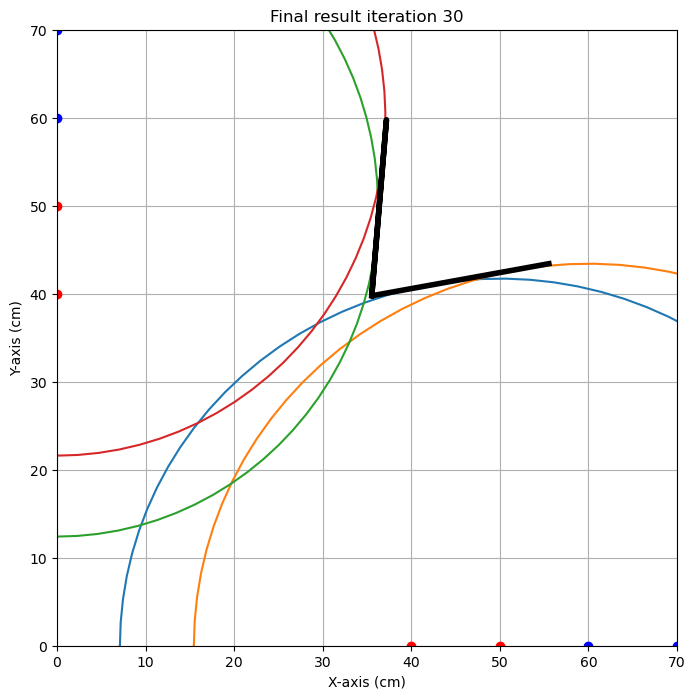

{'alpha': np.float64(10.327242841959858), 'alpha_eps': 0.0, 'beta': np.float64(4.746224791002368), 'beta_eps': 0.0, 'x0': np.float64(35.53142358963715), 'x0_eps': 0.0, 'y0': np.float64(39.7676841598347), 'y0_eps': 0.0}
locatie 1 
x0 target is : 36.4. Gevonden waarde: 38.7 cm met een standaardafwijking van 2.4 cm 
y0 target is : 47.0. Gevonden waarde: 46.4 cm met een standaardafwijking van 4.6 cm 
alpha target is : 0.0. Gevonden waarde: -10.9 graden met een standaardafwijking van 14.9 graad 
beta target is : 8.0. Gevonden waarde: -9.0 graden met een standaardafwijking van 13.2 graad 

locatie 2 
x0 target is : 37.5. Gevonden waarde: 35.5 cm met een standaardafwijking van 0.0 cm 
y0 target is : 40.9. Gevonden waarde: 39.8 cm met een standaardafwijking van 0.0 cm 
alpha target is : 12.0. Gevonden waarde: 10.3 graden met een standaardafwijking van 0.0 graad 
beta target is : 5.0. Gevonden waarde: 4.7 graden met een standaardafwijking van 0.0 graad 



In [11]:
# Voeg hier je meetgegevens van deze iteratie in:

# Vul onderstaande in met jullie gekozen locaties van het reflecterende papier.
targets = {'locatie 1':{'x0': 36.4,
                    'y0': 47,
                    'alpha' : 0,
                    'beta' : 8},
           'locatie 2':{'x0':37.5,
                    'y0':40.9,
                    'alpha' : 12,
                    'beta' : 5}
            }         

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

data ={'locatie 1' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    [30,0,40,0,95.2],
    [35,0,45,0,90.6],
    #[25,0,35,0,ongeldig],
    [0,47.6,0,57.6,73.5],
    [0,52.6,0,62.6,73.6],
    [0,42.6,0,52.6,76.6]
    ]),
       'locatie 2' : pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
    #[30,0,50,0,ongeldig],
    [40,0,60,0,85.8],
    [50,0,70,0,89.1],
    #[0,30,0,50,ongeldig],
    [0,40,0,60,75.2],
    [0,50,0,70,76.8]
    ])
      }
                        
                        
# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(data[locatie])
    print(resultaat[locatie])

                        
# en hier laten we de resultaten als text zien.
for locatie in targets:
    txt='{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 10: Uiteindelijke test met locatie gegeven door TA

test locatie
Running the imaging algorithm with the following data:
   xs  ys  xr  yr     R
0  30   0  50   0  66.3
1  40   0  60   0  66.9
2   0  30   0  50  60.2
3   0  40   0  60  62.6


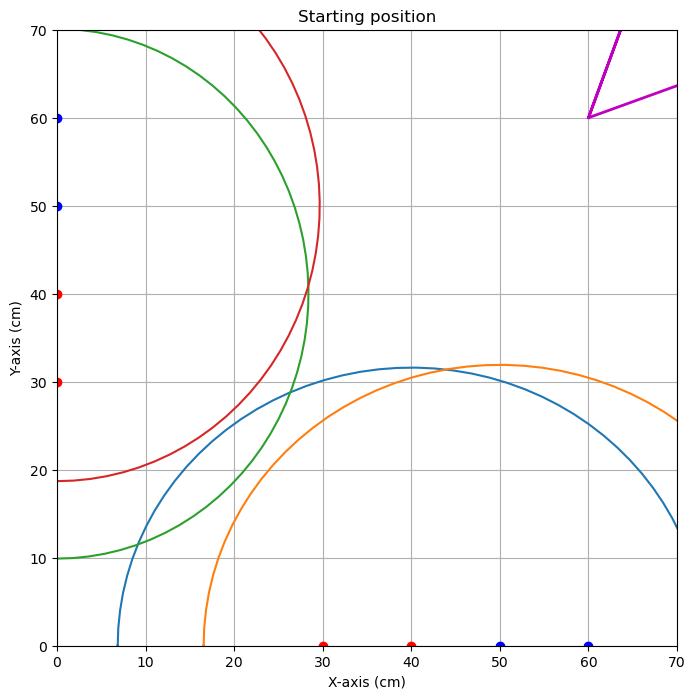


Wacht tot berekeningen klaar zijn; er komen  30 iteraties ...

end iteration 1 with average mismatch=67.966


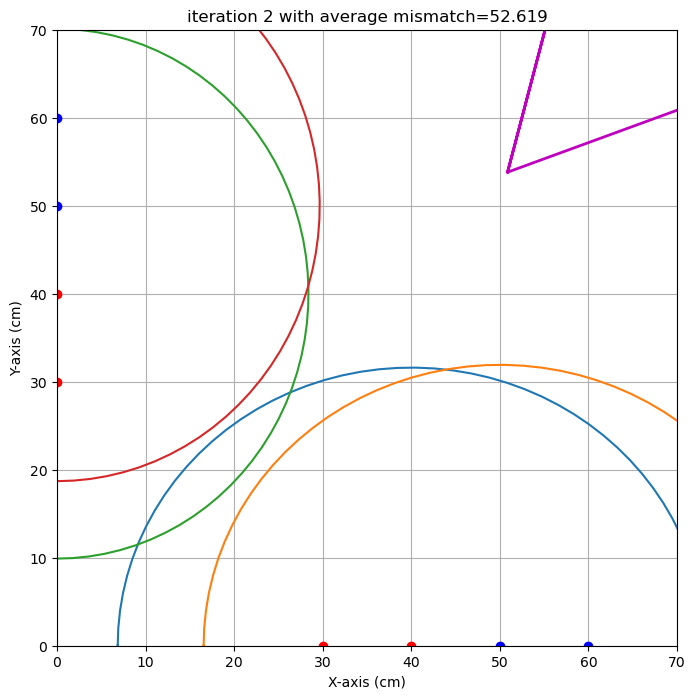

end iteration 2 with average mismatch=52.619


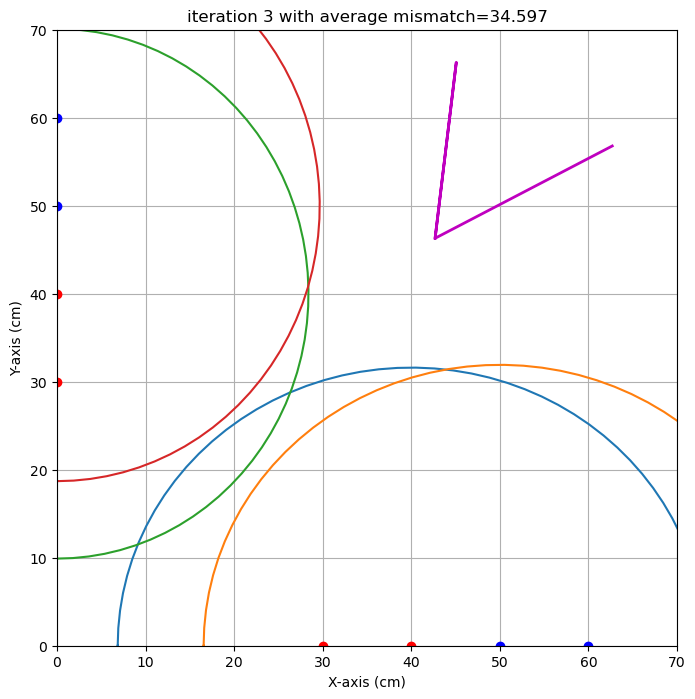

end iteration 3 with average mismatch=34.597


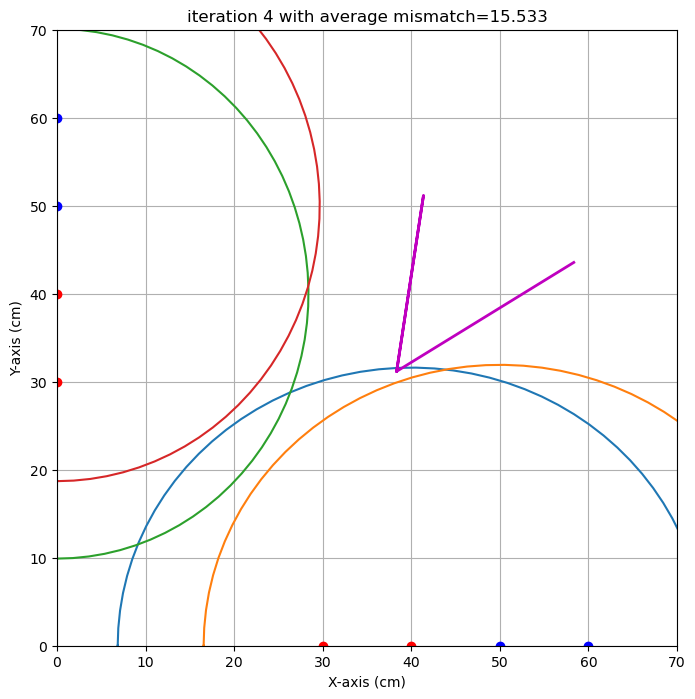

end iteration 4 with average mismatch=15.533


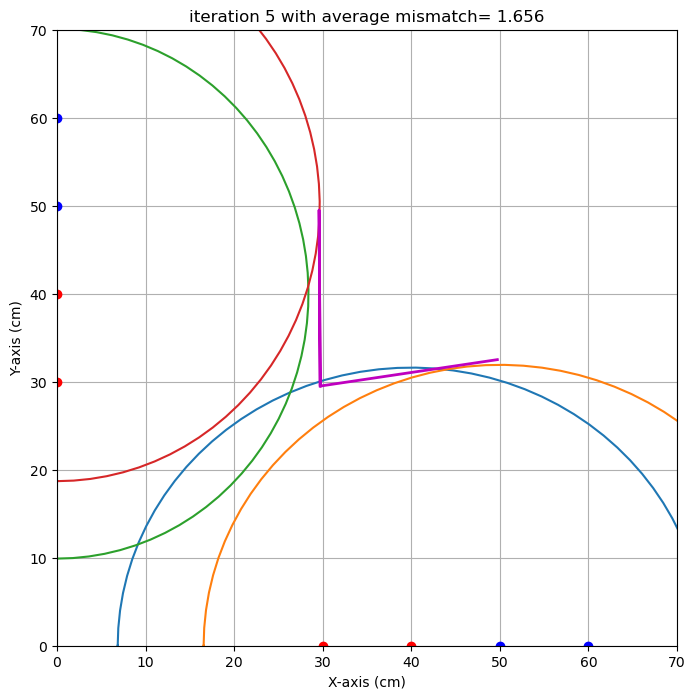

end iteration 5 with average mismatch= 1.656


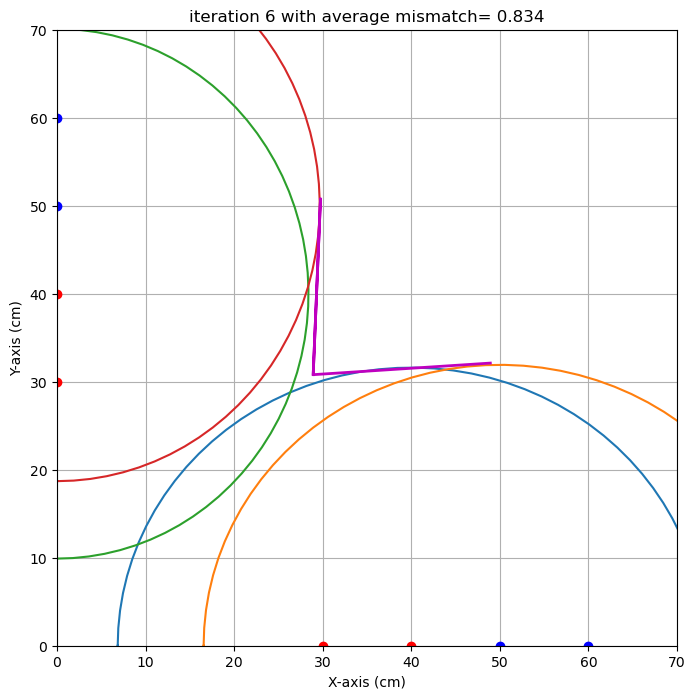

end iteration 6 with average mismatch= 0.834


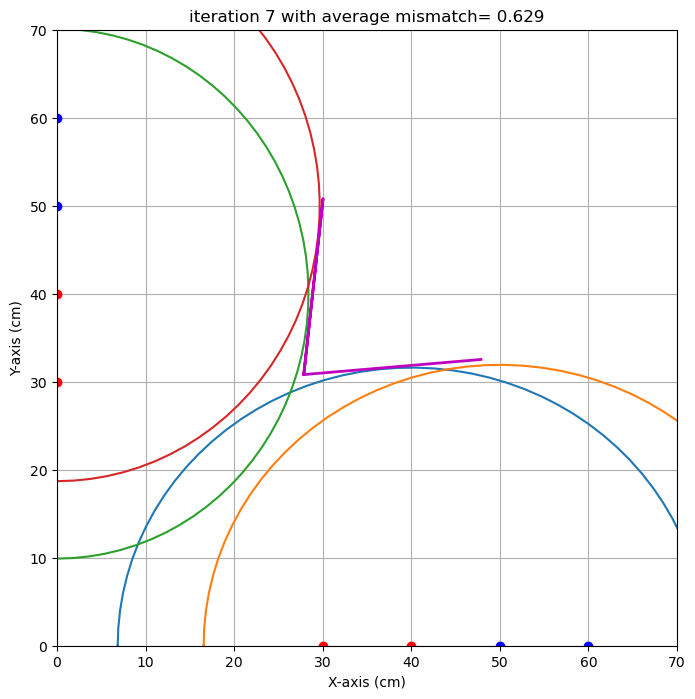

end iteration 7 with average mismatch= 0.629


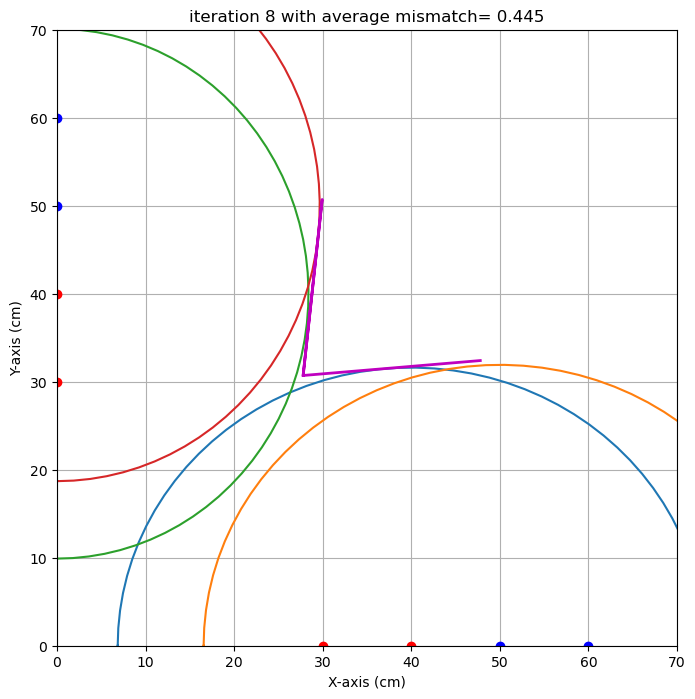

end iteration 8 with average mismatch= 0.445
end iteration 9 with average mismatch= 0.419
end iteration 10 with average mismatch= 0.419
end iteration 11 with average mismatch= 0.419
end iteration 12 with average mismatch= 0.419
end iteration 13 with average mismatch= 0.419
end iteration 14 with average mismatch= 0.419
end iteration 15 with average mismatch= 0.419


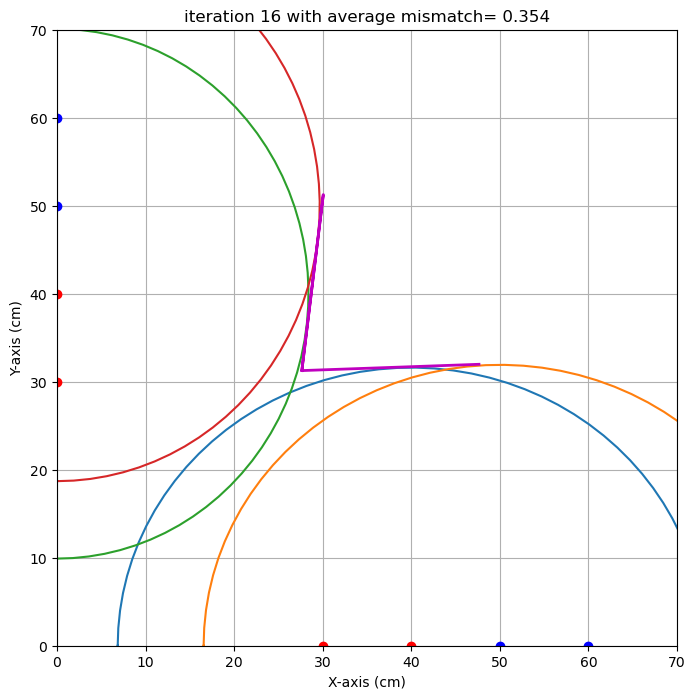

end iteration 16 with average mismatch= 0.354
end iteration 17 with average mismatch= 0.331
end iteration 18 with average mismatch= 0.329
end iteration 19 with average mismatch= 0.327
end iteration 20 with average mismatch= 0.327
end iteration 21 with average mismatch= 0.327
end iteration 22 with average mismatch= 0.327
end iteration 23 with average mismatch= 0.327
end iteration 24 with average mismatch= 0.327
end iteration 25 with average mismatch= 0.327
end iteration 26 with average mismatch= 0.327
end iteration 27 with average mismatch= 0.327
end iteration 28 with average mismatch= 0.327
end iteration 29 with average mismatch= 0.327
Last iteration, also determine uncertainty, wait a while..
wait a little longer....
wait a little longer....
end iteration 30 with average mismatch= 0.327
###############################################################################
end of iteration  30
Best alpha=   2.04 with uncertainty=   2.17
Best beta =   6.89 with uncertainty=   1.54
Best x0   = 

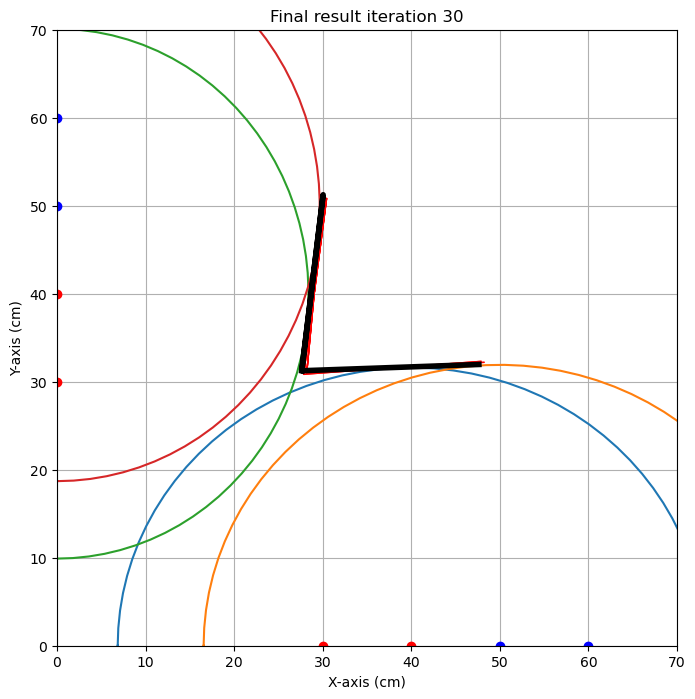

{'alpha': np.float64(2.0380234777254724), 'alpha_eps': np.float64(2.168038832583708), 'beta': np.float64(6.890511234223672), 'beta_eps': np.float64(1.543326377662579), 'x0': np.float64(27.62846806739734), 'x0_eps': np.float64(0.5621794253843468), 'y0': np.float64(31.247904675817917), 'y0_eps': np.float64(0.4056033914570669)}
test locatie 
x0 target is : 26.9. Gevonden waarde: 27.6 cm met een standaardafwijking van 0.6 cm 
y0 target is : 30.5. Gevonden waarde: 31.2 cm met een standaardafwijking van 0.4 cm 
alpha target is : 1.0. Gevonden waarde: 2.0 graden met een standaardafwijking van 2.2 graad 
beta target is : 10.0. Gevonden waarde: 6.9 graden met een standaardafwijking van 1.5 graad 



In [12]:
# Voeg hier je meetgegevens van de uiteindelijke test in:

# Vul onderstaande in met jullie locaties van het reflecterende papier gegeven
# door jullie TA
targets = {'test locatie':{
                    'x0':  26.9,
                    'y0':  30.5,
                    'alpha' :  1,
                    'beta' :  10
                          }
            }
           

# Vul onderstaande matrixen aan met je gemeten meetgegevens.

dataFinalCheck ={'test locatie' :  pd.DataFrame(columns=["xs", "ys", "xr", "yr", "R"], data=[
                    [30,0,50,0,66.3],
                    [40,0,60,0,66.9],
                    [0,30,0,50,60.2],
                    [0,40,0,60,62.6]
                    ])
                }

# Hier runnen we het imaging algoritme:
resultaat = dict()

for locatie in targets:
    print(locatie)
    resultaat[locatie] = imagingDEF.imagingDEF(dataFinalCheck[locatie])
    print(resultaat[locatie])

    
# Run deze cel om jullie resultaten naast elkaar te kunnen zien.
for locatie in targets:
    txt = '{naam} \r\nx0 target is : {x0Target:.1f}. Gevonden waarde: {x0:.1f} cm met een standaardafwijking van {x0_eps:.1f} cm \r\n'
    txt = txt + 'y0 target is : {y0Target:.1f}. Gevonden waarde: {y0:.1f} cm met een standaardafwijking van {y0_eps:.1f} cm \r\n'
    txt = txt + 'alpha target is : {alphaTarget:.1f}. Gevonden waarde: {alpha:.1f} graden met een standaardafwijking van {alpha_eps:.1f} graad \r\n'
    txt = txt + 'beta target is : {betaTarget:.1f}. Gevonden waarde: {beta:.1f} graden met een standaardafwijking van {beta_eps:.1f} graad \r\n'
    print(txt.format(naam = locatie,
                     x0Target=targets[locatie]['x0'],
                     x0=resultaat[locatie]['x0'],
                     x0_eps=resultaat[locatie]['x0_eps'],
                     y0Target=targets[locatie]['y0'],
                     y0=resultaat[locatie]['y0'],
                     y0_eps=resultaat[locatie]['y0_eps'],
                     alphaTarget=targets[locatie]['alpha'],
                     alpha=resultaat[locatie]['alpha'],
                     alpha_eps=resultaat[locatie]['alpha_eps'],
                     betaTarget=targets[locatie]['beta'],
                     beta=resultaat[locatie]['beta'],
                     beta_eps=resultaat[locatie]['beta_eps']))

## Opdracht 11: Leerdoelen.
#### algoritme [Nynke]
<img src="AlgoritmeN1.png" width="400">
<img src="AlgoritmeN2.png" width="400">

#### algoritme [Wobbe]

<img src="AlgoritmeW.png" width="400">

#### algoritme [Jesse]

<img src="AlgoritmeJ.png" width="400">

## Opdracht 8: Iteratie1+. 14:25
### Synthese
Maak een nieuwe blokkenschema op A3 van wat je nu als algoritme gaat proberen. Als het kleine wijzigingen zijn ten opzichte van een vorige iteratie, kras dan gewoon in de oude blokkenschema als dat duidelijk blijft. Maak een foto en zet die hieronder. Zorg dat het iteratienummer goed op de foto te zien is.

Figuur: ![Alt](Iteratie1.png)

Figuur: ![Alt](Iteratie2.png)

Veranderingen van iteratie 2 -> Afstand tussen bron en ontvanger vergroot, zodat er een grotere kans is op geldige waarde (door hoek) en y-as keuze onafhankelijk van uitkomst x-as gehouden.